In [1]:
!nvidia-smi

Thu Aug 28 06:49:59 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   43C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

nvidia-smi ย่อมาจาก "NVIDIA System Management Interface" ซึ่งเป็นเครื่องมือบรรทัดคำสั่งที่มาพร้อมกับไดรเวอร์ของการ์ดจอ NVIDIA โดยมีไว้สำหรับแสดงและจัดการข้อมูลสถานะของ GPU ในเครื่อง ตัวอย่างของข้อมูลที่เครื่องมือนี้แสดงได้แก่

• ข้อมูลการใช้งาน GPU (เช่น % การใช้งาน, อุณหภูมิ) • การใช้หน่วยความจำบนการ์ดจอ • รายการโปรเซสที่กำลังใช้งาน GPU

ส่วนเครื่องหมาย "!" ที่อยู่หน้าคำสั่ง (เช่น !nvidia-smi) มักจะใช้ในสภาพแวดล้อมที่รองรับการรันคำสั่ง shell ผ่าน notebook (เช่น Jupyter Notebook หรือ Google Colab) เพื่อเรียกใช้งานคำสั่งในระบบปฏิบัติการโดยตรง

สรุปคือ คำสั่ง "!nvidia-smi" เป็นวิธีหนึ่งในการเรียกดูสถานะและการจัดการของ GPU ผ่าน command-line ในสภาพแวดล้อมที่อนุญาตให้รันคำสั่ง shell ได้ครับ

In [2]:
import os
import matplotlib.pyplot as plt
from PIL import Image

import os

 • นำเข้ามอดูล os ซึ่งให้ฟังก์ชันที่ใช้ในการโต้ตอบกับระบบปฏิบัติการ เช่น การจัดการไฟล์ โฟลเดอร์ และจัดการกับเส้นทางไฟล์


import matplotlib.pyplot as plt

 • นำเข้ามอดูล matplotlib.pyplot โดยกำหนดชื่อย่อว่า plt ซึ่งใช้สำหรับการสร้างกราฟและการแสดงผลข้อมูลเชิงกราฟิก


from PIL import Image

 • นำเข้าคลาส Image จากไลบรารี PIL (Pillow) ซึ่งเป็นไลบรารีสำหรับการจัดการรูปภาพใน Python เช่น เปิด อ่าน แก้ไข และบันทึกรูปภาพ


โดยรวมแล้วโค้ดนี้ถือเป็นการเตรียมเครื่องมือพื้นฐานสำหรับงานที่เกี่ยวกับการประมวลผลและแสดงผลรูปภาพใน Python ครับ

In [3]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("pcbreviglieri/pneumonia-xray-images")

print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/pneumonia-xray-images


โค้ดนี้ใช้โมดูล kagglehub ที่ช่วยให้สามารถดาวน์โหลด dataset จาก Kaggle ได้โดยตรง โดยมีรายละเอียดแต่ละบรรทัดดังนี้:


import kagglehub

 • นำเข้าโมดูล kagglehub เพื่อเรียกใช้ฟังก์ชันที่เกี่ยวข้องกับการดาวน์โหลด dataset จาก Kaggle



Download latest version

• คอมเมนต์บอกว่าโค้ดส่วนถัดไปใช้สำหรับดาวน์โหลดเวอร์ชันล่าสุดของ dataset



path = kagglehub.dataset_download("pcbreviglieri/pneumonia-xray-images")

 • เรียกฟังก์ชัน dataset_download ของโมดูล kagglehub โดยส่งชื่อ dataset "pcbreviglieri/pneumonia-xray-images"
 • ผลลัพธ์ที่ได้ (ซึ่งน่าจะเป็น path ที่เก็บไฟล์ dataset ที่ดาวน์โหลดมา) จะถูกเก็บไว้ในตัวแปร path



print("Path to dataset files:", path)

 • แสดงผลข้อความพร้อมกับตัวแปร path เพื่อบอกว่าที่อยู่ไฟล์ของ dataset ที่ดาวน์โหลดมานั้นอยู่ที่ไหน


สรุปคือ โค้ดนี้จะทำการดาวน์โหลด dataset "pneumonia-xray-images" จาก Kaggle และแสดงที่อยู่ของไฟล์ dataset ที่ดาวน์โหลดลงมาให้ทราบครับ

In [4]:
os.listdir(path)

['val', 'test', 'train']

คำสั่ง os.listdir(path) ใช้สำหรับแสดงรายชื่อไฟล์และโฟลเดอร์ทั้งหมดที่อยู่ใน directory ที่ระบุด้วย path ในกรณีนี้ path เป็นตัวแปรที่ได้จากการดาวน์โหลด dataset ผ่าน kagglehub โดยคำสั่งนี้จะส่งกลับเป็นลิสต์ของชื่อไฟล์และโฟลเดอร์ภายใน directory นั้น

ตัวอย่างเช่น ถ้า path ชี้ไปที่โฟลเดอร์ dataset ที่มีไฟล์ "data.csv" และโฟลเดอร์ "images" คำสั่ง os.listdir(path) จะคืนค่า ["data.csv", "images"]

จุดประสงค์หลักคือเพื่อให้คุณสามารถตรวจสอบและเข้าถึงไฟล์ต่าง ๆ สำหรับการประมวลผลหรือใช้งานต่อไปครับ

In [5]:
train_path = os.path.join(path, 'train')
train_path

'/kaggle/input/pneumonia-xray-images/train'

ในโค้ดนี้คำสั่ง

train_path = os.path.join(path, 'train')

มีความหมายและทำงานดังนี้:

ฟังก์ชัน os.path.join ใช้สำหรับการเชื่อมต่อ (join) เส้นทาง (path) หลาย ๆ ส่วนเข้าด้วยกันในรูปแบบที่ถูกต้องตามระบบปฏิบัติการที่ใช้ (เช่น Windows ใช้เครื่องหมาย \ แทน / ใน UNIX-based systems)

โค้ดนี้กำลังเชื่อมต่อเส้นทางที่เก็บไว้ในตัวแปร path (ซึ่งเป็นที่อยู่ของ dataset ที่ดาวน์โหลดมา) กับชื่อโฟลเดอร์ 'train' เพื่อสร้างเส้นทางไปยังโฟลเดอร์ย่อยที่ชื่อว่า train ภายใน dataset

เมื่อพิมพ์ออกมา (หรือแสดงค่า) ตัวแปร train_path จะเป็นสตริงที่บ่งบอกที่อยู่ของโฟลเดอร์ "train" ใน dataset เช่น ถ้า path เป็น "C:/Datasets/pneumonia-xray-images" ผลลัพธ์จะเป็น "C:/Datasets/pneumonia-xray-images/train"

สรุปคือ คำสั่งนี้ใช้เพื่อประกอบเส้นทางไปยังโฟลเดอร์ "train" ที่อยู่ภายใน dataset ครับ

In [6]:
classes = os.listdir(train_path)
classes

['normal', 'opacity']

คำสั่ง

classes = os.listdir(train_path)

ทำหน้าที่ให้แสดงรายชื่อไฟล์และโฟลเดอร์ภายในโฟลเดอร์ train ที่อยู่ในตัวแปร train_path โดยผลลัพธ์ที่ได้จะถูกเก็บในตัวแปร classes หลังจากนั้น การพิมพ์ตัวแปร classes (หรือเพียงแสดงค่าใน interactive environment) จะเห็นรายชื่อไฟล์หรือโฟลเดอร์ที่มีอยู่ใน train_path

โดยในบริบทของ dataset pneumonia-xray ซึ่งมักจะแบ่งข้อมูลออกเป็นกลุ่ม (classes) เช่น "NORMAL" และ "PNEUMONIA" อาจเป็นว่าภายใน train_path จะมีโฟลเดอร์ที่ชื่อเหล่านี้ ซึ่งแต่ละโฟลเดอร์จะมีไฟล์ภาพสำหรับแต่ละประเภท

สรุปคือ คำสั่งนี้ใช้ในการเรียกดูชื่อของคลาสที่มีอยู่ในโฟลเดอร์ train โดยแต่ละชื่อก็คือคลาสที่อยู่ใน dataset นั่นเองครับ

In [7]:
normal_path = os.path.join(train_path, 'NORMAL')
pneumonia_path = os.path.join(train_path, 'PNEUMONIA')

โค้ดนี้สร้างเส้นทางไปยังโฟลเดอร์ย่อยภายใน train_path ดังนี้:

normal_path = os.path.join(train_path, 'NORMAL')
 • ใช้ฟังก์ชัน os.path.join เพื่อเชื่อมต่อเส้นทางของโฟลเดอร์หลัก (train_path) เข้ากับชื่อโฟลเดอร์ย่อย 'NORMAL'
 • ผลลัพธ์คือ normal_path จะชี้ไปที่โฟลเดอร์ที่เก็บข้อมูลที่จัดหมวดหมู่เป็น "NORMAL"

pneumonia_path = os.path.join(train_path, 'PNEUMONIA')
 • ทำการเชื่อมต่อเส้นทางของ train_path กับชื่อโฟลเดอร์ 'PNEUMONIA'
 • ทำให้ pneumonia_path ชี้ไปที่โฟลเดอร์ข้อมูลสำหรับหมวด "PNEUMONIA"

สรุปคือ โค้ดส่วนนี้กำลังสร้างเส้นทาง (path) ไปยังไฟล์หรือโฟลเดอร์ของข้อมูลที่ถูกจัดแบ่งประเภท (class) โดยในที่นี้มีสองประเภทคือ "NORMAL" และ "PNEUMONIA" ครับ

In [8]:
normal_path

'/kaggle/input/pneumonia-xray-images/train/NORMAL'

โดยการพิมพ์ normal_path ใน interactive environment (เช่น Jupyter Notebook หรือ Python shell) จะทำให้เห็นค่าของตัวแปร normal_path ซึ่งเก็บเส้นทางที่สร้างไว้สำหรับโฟลเดอร์ที่ชื่อ "NORMAL" ภายในโฟลเดอร์ train

โดยค่า output ที่ได้อาจจะเป็น string ที่ระบุเส้นทางเต็ม เช่น

"C:/Datasets/pneumonia-xray-images/train/NORMAL"

หรือในระบบอื่น ๆ ก็จะเป็นรูปแบบของ path ที่สอดคล้องกับระบบปฏิบัติการนั้น ๆ ครับ

In [9]:
pneumonia_path

'/kaggle/input/pneumonia-xray-images/train/PNEUMONIA'

โดยการพิมพ์ pneumonia_path จะทำให้เห็นค่าของตัวแปร pneumonia_path ซึ่งเป็นเส้นทางที่สร้างไว้สำหรับโฟลเดอร์ที่ชื่อ "PNEUMONIA" ภายในโฟลเดอร์ train ไฟล์หรือโฟลเดอร์นี้น่าจะเก็บข้อมูลภาพที่มีคำวินิจฉัยว่า PNEUMONIA ผลลัพธ์ที่ได้จะเป็น string ที่ระบุเส้นทางเต็ม เช่น

"C:/Datasets/pneumonia-xray-images/train/PNEUMONIA"

หรือในระบบที่ต่างกันก็จะมีรูปแบบเส้นทางที่สอดคล้องกับระบบปฏิบัติการนั้น ๆ ครับ


Sample image files in 'normal' class:
['NORMAL2-IM-0771-0001.jpeg', 'IM-0675-0001.jpeg', 'IM-0421-0001.jpeg', 'NORMAL2-IM-0531-0001.jpeg', 'NORMAL2-IM-0416-0001-0002.jpeg']

Sample image files in 'opacity' class:
['person1180_virus_2010.jpeg', 'person1230_virus_2081.jpeg', 'person124_virus_238.jpeg', 'person746_virus_1369.jpeg', 'person588_bacteria_2422.jpeg']


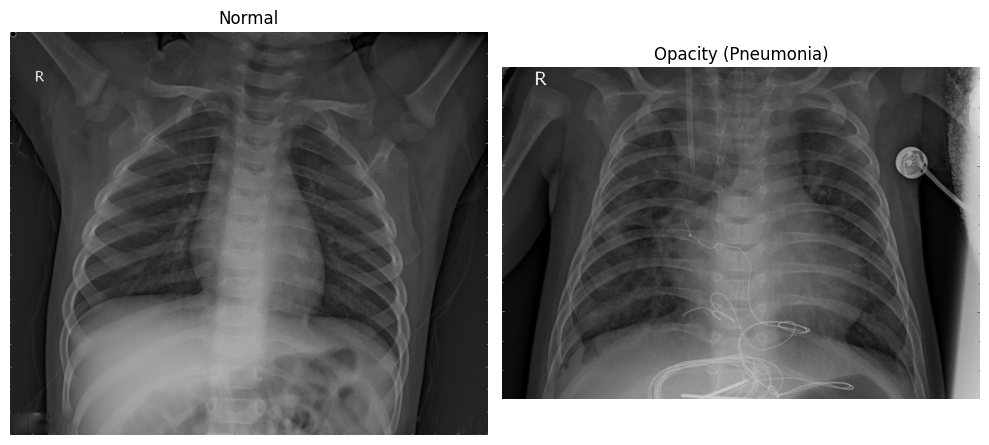

In [10]:
normal_path = os.path.join(train_path, 'normal')
opacity_path = os.path.join(train_path, 'opacity')

print("\nSample image files in 'normal' class:")
print(os.listdir(normal_path)[:5])

print("\nSample image files in 'opacity' class:")
print(os.listdir(opacity_path)[:5])

# Load and display a few sample images
plt.figure(figsize=(10, 5))

# Display a normal image
normal_img_path = os.path.join(normal_path, os.listdir(normal_path)[0])
normal_img = Image.open(normal_img_path)
plt.subplot(1, 2, 1)
plt.imshow(normal_img, cmap='gray')
plt.title('Normal')
plt.axis('off')

# Display an opacity image (representing pneumonia)
opacity_img_path = os.path.join(opacity_path, os.listdir(opacity_path)[0])
opacity_img = Image.open(opacity_img_path)
plt.subplot(1, 2, 2)
plt.imshow(opacity_img, cmap='gray')
plt.title('Opacity (Pneumonia)')
plt.axis('off')

plt.tight_layout()
plt.show()

โค้ดส่วนนี้ทำงานดังนี้:


กำหนดเส้นทางของข้อมูลในสองคลาส
 - normal_path = os.path.join(train_path, 'normal')
  • สร้างตัวแปร normal_path ให้เป็นเส้นทางไปยังโฟลเดอร์ "normal" ภายในโฟลเดอร์ train
 - opacity_path = os.path.join(train_path, 'opacity')
  • สร้างตัวแปร opacity_path ให้เป็นเส้นทางไปยังโฟลเดอร์ "opacity" ภายในโฟลเดอร์ train ซึ่งในที่นี้อาจจะเก็บข้อมูลภาพที่มีลักษณะ "opacity" ซึ่งอาจแสดงถึงอาการของ pneumonia


การแสดงรายชื่อไฟล์ตัวอย่าง
 - print("\nSample image files in 'normal' class:")
  • พิมพ์ข้อความหัวข้อ
 - print(os.listdir(normal_path)[:5])
  • แสดงรายชื่อไฟล์ในโฟลเดอร์ normal เพียง 5 รายการแรก
 - print("\nSample image files in 'opacity' class:")
  • พิมพ์หัวข้อสำหรับคลาส opacity
 - print(os.listdir(opacity_path)[:5])
  • แสดงรายชื่อไฟล์ตัวอย่างในโฟลเดอร์ opacity เพียง 5 รายการแรก


การโหลดและแสดงภาพตัวอย่างโดยใช้ matplotlib
 - plt.figure(figsize=(10, 5))
  • สร้าง figure สำหรับการ plot ภาพที่มีขนาด 10x5 นิ้ว
 - โหลดภาพจากคลาส normal
  • normal_img_path = os.path.join(normal_path, os.listdir(normal_path)[0])
   รับ path ของไฟล์ภาพตัวแรกในโฟลเดอร์ normal
  • normal_img = Image.open(normal_img_path)
   เปิดภาพด้วยฟังก์ชัน Image.open
 - plt.subplot(1, 2, 1)
  • กำหนด subplot แรกใน layout 1 แถว 2 คอลัมน์
 - plt.imshow(normal_img, cmap='gray')
  • แสดงภาพในสีแบบ grayscale
 - plt.title('Normal')
  • กำหนดชื่อหัวเรื่องของ subplot เป็น "Normal"
 - plt.axis('off')
  • ปิดการแสดงแกนของ plot


- โหลดภาพจากคลาส opacity
  • opacity_img_path = os.path.join(opacity_path, os.listdir(opacity_path)[0])
   รับ path ของไฟล์ภาพตัวแรกในโฟลเดอร์ opacity
  • opacity_img = Image.open(opacity_img_path)
   เปิดภาพด้วยฟังก์ชัน Image.open
 - plt.subplot(1, 2, 2)
  • กำหนด subplot ที่สองใน layout 1 แถว 2 คอลัมน์
 - plt.imshow(opacity_img, cmap='gray')
  • แสดงภาพด้วยสีแบบ grayscale
 - plt.title('Opacity (Pneumonia)')
  • กำหนดหัวเรื่องของ subplot เป็น "Opacity (Pneumonia)"
 - plt.axis('off')
  • ปิดการแสดงแกน


plt.tight_layout()
 - จัดวางตำแหน่ง subplot ให้อยู่ใน layout ที่กระชับและไม่ทับซ้อนกัน


plt.show()
 - แสดงผลภาพทั้งหมดในหน้าต่าง plot


สรุป โค้ดนี้ทำการแสดงรายชื่อไฟล์ภาพตัวอย่างจากโฟลเดอร์ normal และ opacity จากนั้นโหลดและแสดงภาพตัวอย่างของแต่ละคลาสในรูปแบบ grayscale โดยใช้ matplotlib เพื่อแสดงผลในสอง subplot ครับ

In [11]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import os
from collections import Counter
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

import tensorflow as tf

โค้ดนี้ใช้สำหรับนำเข้า (import) ไลบรารีและโมดูลที่จำเป็นสำหรับงานด้านการประมวลผลภาพและการเรียนรู้เชิงลึก (deep learning) ด้วย TensorFlow/Keras โดยมีการอธิบายดังนี้:


from tensorflow.keras.preprocessing.image import ImageDataGenerator
 • นำเข้า class ImageDataGenerator ที่ใช้สำหรับสร้างชุดข้อมูลภาพแบบไดนามิก (data augmentation) และสำหรับการโหลดภาพเข้าโมเดล


import os
 • นำเข้าโมดูล os ซึ่งใช้สำหรับจัดการกับระบบไฟล์และโฟลเดอร์ (เช่น สร้าง path, เรียกดูไฟล์)


from collections import Counter
 • นำเข้า Counter จาก collections เพื่อนับจำนวนข้อมูลในกลุ่มต่าง ๆ (หรือใช้สำหรับวิเคราะห์ distribution ของ class)


from sklearn.utils.class_weight import compute_class_weight
 • นำเข้าฟังก์ชัน compute_class_weight จาก scikit-learn ซึ่งใช้สำหรับคำนวณ class weights เพื่อแก้ไขปัญหาชุดข้อมูลที่ไม่สมดุล (imbalanced dataset) ในการฝึกโมเดล


import numpy as np
 • นำเข้าไลบรารี numpy ซึ่งเป็นไลบรารีพื้นฐานสำหรับการคำนวณเชิงตัวเลขและการจัดการ array


import tensorflow as tf
 • นำเข้าไลบรารี TensorFlow ซึ่งเป็นพื้นฐานสำหรับงาน deep learning และงานประมวลผลอื่น ๆ ด้วย GPU


โดยสรุป โค้ดส่วนนี้เป็นการตั้งค่าและนำเข้าทูลส์ (tools) ที่จำเป็นสำหรับการจัดการและเพิ่มประสิทธิภาพของข้อมูลภาพรวมถึงการเตรียมความพร้อมสำหรับการฝึกฝนโมเดล deep learning ด้วย TensorFlow/Keras ครับ

In [12]:
train_dir = os.path.join(path, 'train')
val_dir = os.path.join(path, 'val')
test_dir = os.path.join(path, 'test')

img_size = (350, 350)
batch_size = 32

# Create ImageDataGenerators
# Data augmentation for training
train_datagen = ImageDataGenerator(
    rescale=1./255,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
)

# No data augmentation for validation and test, only rescaling
val_test_datagen = ImageDataGenerator(rescale=1./255)

# Load images from directories
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='binary',
    color_mode='grayscale'
)

validation_generator = val_test_datagen.flow_from_directory(
    val_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='binary',
    color_mode='grayscale'
)

test_generator = val_test_datagen.flow_from_directory(
    test_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='binary',
    shuffle=False, # Keep data in order for evaluation
    color_mode='grayscale'
)

print("Data generators created:")
print(f"Training generator: {train_generator}")
print(f"Validation generator: {validation_generator}")
print(f"Test generator: {test_generator}")

Found 4192 images belonging to 2 classes.
Found 1040 images belonging to 2 classes.
Found 624 images belonging to 2 classes.
Data generators created:
Training generator: <keras.src.legacy.preprocessing.image.DirectoryIterator object at 0x7cf1eefc7470>
Validation generator: <keras.src.legacy.preprocessing.image.DirectoryIterator object at 0x7cf1ef075a60>
Test generator: <keras.src.legacy.preprocessing.image.DirectoryIterator object at 0x7cf1ef018a10>


โค้ดส่วนนี้เป็นการเตรียมข้อมูลสำหรับการฝึกสอนโมเดล deep learning โดยใช้ Keras ImageDataGenerator เพื่อโหลดและปรับเปลี่ยนข้อมูลภาพจากโฟลเดอร์ต่าง ๆ ดังนี้:


กำหนดไดเรกทอรีสำหรับชุดข้อมูล
 - train_dir, val_dir, test_dir
  • ใช้ os.path.join เพื่อรวม path หลัก (path) เข้ากับชื่อโฟลเดอร์ "train", "val" และ "test" ตามลำดับ
  • ไดเรกทอรีเหล่านี้จะเก็บชุดข้อมูลสำหรับฝึกสอน ตรวจสอบ และทดสอบ


กำหนดขนาดของภาพและขนาดล็อต
 - img_size = (350, 350)
  • เปลี่ยนขนาดภาพให้มีความกว้างและความสูง 350 พิกเซล
 - batch_size = 32
  • จำนวนภาพในแต่ละล็อตของข้อมูลที่ส่งเข้าสู่โมเดล


การสร้าง ImageDataGenerator
 - train_datagen
  • สำหรับชุดข้อมูลฝึกสอน มีการทำ data augmentation เพื่อเพิ่มความหลากหลายของข้อมูลด้วยพารามิเตอร์:
   - rescale=1./255: ปรับขนาดค่าพิกเซลให้อยู่ในช่วง 0-1
   - shear_range=0.2: ทำการ shear (เอียงภาพ)
   - zoom_range=0.2: ซูมเข้าออกในช่วงที่กำหนด
   - horizontal_flip=True: สลับภาพแนวนอน
 - val_test_datagen
  • สำหรับชุดข้อมูลตรวจสอบ (validation) และทดสอบ (test) ไม่มีการเพิ่มข้อมูล (augmentation) มีเฉพาะการ rescaling ค่า pixel เท่านั้น


การโหลดภาพจากไดเรกทอรี
 - train_generator
  • ใช้ train_datagen.flow_from_directory เพื่ออ่านภาพจาก train_dir โดยระบุ:
   - target_size=img_size: ปรับขนาดภาพ
   - batch_size=32: จำนวนภาพในแต่ละล็อต
   - class_mode='binary': กำหนดให้เป็นปัญหาการจำแนกประเภทแบบไบนารี (0 หรือ 1)
   - color_mode='grayscale': โหลดภาพในโหมด grayscale
 - validation_generator
  • ใช้ val_test_datagen.flow_from_directory เพื่อโหลดภาพจาก val_dir ด้วยพารามิเตอร์เดียวกันกับ train_generator (ยกเว้นเรื่อง data augmentation)
 - test_generator
  • โหลดภาพจาก test_dir โดยระบุ shuffle=False เพื่อให้ชุดข้อมูลไม่สลับลำดับ (สะดวกสำหรับการประเมินผล)


การแสดงผลข้อมูลที่สร้างขึ้น
 • print() ใช้สำหรับแสดงข้อความและตัวแปรที่สร้างขึ้นในแต่ละ generator


สรุปแล้ว โค้ดนี้เป็นการเตรียมและโหลดข้อมูลภาพจากไดเรกทอรี 3 ชุด (ฝึก, ตรวจสอบ, ทดสอบ) พร้อมกับปรับเปลี่ยน (augmentation) เฉพาะในชุดข้อมูลฝึกสอน ซึ่งเป็นขั้นตอนพื้นฐานในการเตรียมข้อมูลสำหรับการฝึกโมเดล deep learning ครับ

In [13]:
batchX, batchY = next(train_generator)
print('Batch shape=%s, min=%.3f, max=%.3f' % (batchX.shape, batchX.min(), batchX.max()))

Batch shape=(32, 350, 350, 1), min=0.000, max=1.000


โค้ดนี้ทำงานตามขั้นตอนดังนี้:


batchX, batchY = next(train_generator)
 • ใช้ next() เพื่อดึง batch หนึ่ง (ภาพและป้ายกำกับ) จาก train_generator ซึ่งเป็น generator ที่สร้างขึ้นก่อนหน้านี้จากข้อมูลฝึกสอน
 • batchX คือ array ของภาพที่อยู่ใน batch นั้น (โดยมีขนาดและรูปแบบที่กำหนดไว้ใน train_generator)
 • batchY คือ array ของป้ายกำกับ corresponding labels สำหรับภาพใน batch นั้น


print('Batch shape=%s, min=%.3f, max=%.3f' % (batchX.shape, batchX.min(), batchX.max()))
 • พิมพ์ข้อความที่แสดงข้อมูลของ batchX
  - batchX.shape แสดงขนาดของ array (ตัวอย่างเช่น (32, 350, 350, 1) ถ้าเป็น 32 ภาพ แต่ละภาพมีขนาด 350×350 พิกเซลและเป็น grayscale)
  - batchX.min() จะแสดงค่าน้อยที่สุดใน batchX เพื่อให้ทราบว่าค่าพิกเซลต่ำสุดเท่าใด (เนื่องจากมีการ rescale ค่าโดยใช้ 1./255 ค่าพิกเซลควรจะอยู่ในช่วง 0-1)
  - batchX.max() จะแสดงค่าสูงสุดใน batchX


สรุปคือ เมื่อรันโค้ดนี้จะดึงข้อมูลภาพและป้ายกำกับจาก generator ขึ้นมาแล้วพิมพ์ขนาดของ batch พร้อมทั้งค่าสูงสุดและต่ำสุดของพิกเซลในภาพ ซึ่งช่วยให้ตรวจสอบได้ว่าข้อมูลถูกเตรียมอย่างถูกต้อง เช่น ค่า rescale ให้เป็นช่วง 0-1 แล้วหรือไม่ครับ

In [14]:
labels = list(train_generator.class_indices.keys())
labels

['normal', 'opacity']

โค้ดนี้ทำงานดังนี้:


train_generator.class_indices
 • เป็น dictionary ที่เก็บ mapping ระหว่างชื่อคลาสและค่าที่ถูกเข้ารหัสไว้ (ตัวเลข) โดยที่ key คือชื่อคลาสและ value คือ label ที่ใช้ในการฝึก
  เช่น {'normal': 0, 'opacity': 1} หรือ {'PNEUMONIA': 0, 'NORMAL': 1} ขึ้นอยู่กับโครงสร้างข้อมูล


list(train_generator.class_indices.keys())
 • แปลง keys ของ dictionary ให้เป็น list ซึ่งจะเป็นรายชื่อของคลาสทั้งหมดในชุดข้อมูลฝึก


labels
 • เมื่อเราเรียกใช้ labels หลังจากที่กำหนดค่าแล้ว จะได้ผลลัพธ์เป็น list ของชื่อคลาสที่ใช้ในการฝึกสอนโมเดล


สรุปโค้ดนี้ใช้สำหรับดึงรายชื่อคลาสที่อยู่ใน train_generator ออกมาในรูปแบบของ list ทำให้สามารถตรวจสอบหรือใช้งานชื่อคลาสได้สะดวกครับ

In [15]:
Counter(train_generator.classes)

Counter({np.int32(0): 1082, np.int32(1): 3110})

โค้ดนี้ทำงานดังนี้:
• train_generator.classes
 - เป็นอาร์เรย์ที่เก็บเลข labels สำหรับแต่ละตัวอย่างภาพในชุดข้อมูลฝึก ซึ่งแต่ละตัวเลขจะเป็นการเข้ารหัสของคลาสที่สอดคล้องกับ class_indices ที่กำหนดไว้ (เช่น 0 สำหรับ normal, 1 สำหรับ opacity)
• Counter(train_generator.classes)
 - ใช้ฟังก์ชัน Counter จาก collections (ที่นำเข้ามาแล้วก่อนหน้านี้) เพื่อทำการนับจำนวนของแต่ละ label ในอาร์เรย์ train_generator.classes
 - ผลลัพธ์ที่ได้จะเป็น dictionary-like object โดย key คือ label (เช่น 0 หรือ 1) และ value คือจำนวนภาพในแต่ละคลาส
สรุปโค้ดนี้ช่วยให้เราทราบว่าในชุดข้อมูลฝึกแต่ละคลาสมีจำนวนภาพเท่าไหร่ ทำให้ง่ายต่อการตรวจสอบความสมดุลของข้อมูล (class distribution) ครับ

In [16]:
weights = compute_class_weight(class_weight = 'balanced', classes = np.unique(train_generator.classes), y = train_generator.classes)
weights

array([1.93715342, 0.67395498])

โค้ดนี้ใช้ฟังก์ชัน compute_class_weight จาก scikit-learn เพื่อคำนวณน้ำหนักของแต่ละคลาสในชุดข้อมูลฝึกโดยอัตโนมัติให้เหมาะสมกับการแก้ปัญหาข้อมูลที่ไม่สมดุล โดยมีรายละเอียดดังนี้:


class_weight = 'balanced'
 • ระบุว่าให้คำนวณน้ำหนักแบบ balanced โดยค่าน้ำหนักจะถูกคำนวณใหม่โดยอิงจากความถี่ของแต่ละคลาสในข้อมูล ผลคือคลาสที่มีจำนวนน้อยจะมีค่าน้ำหนักสูงกว่าเพื่อปรับสมดุล


classes = np.unique(train_generator.classes)
 • np.unique(train_generator.classes) จะคืนค่ารายการของ label ที่ไม่ซ้ำกันใน train_generator.classes ซึ่งเป็นข้อมูล labels ของแต่ละตัวอย่างในชุดข้อมูลฝึก


y = train_generator.classes
 • กำหนดให้ y เป็นข้อมูล labels ของตัวอย่างในชุดข้อมูลฝึก ที่ใช้สำหรับคำนวณน้ำหนักของแต่ละคลาส


ผลลัพธ์ที่ได้ในตัวแปร weights จะเป็นอาร์เรย์หรือค่าที่บอกค่าน้ำหนักของแต่ละคลาสตามลำดับ ซึ่งสามารถนำไปใช้ปรับปรุงการฝึกโมเดล (เช่น การส่งผ่านค่า class_weight ใน model.fit)


สรุปแล้ว โค้ดนี้จะช่วยให้คุณได้ค่าน้ำหนักของแต่ละคลาสในชุดข้อมูลฝึกที่คำนวณตามสูตร balanced เพื่อใช้แก้ปัญหาข้อมูลที่ไม่สมดุลในระหว่างการฝึกโมเดลครับ

In [17]:
cw = dict(zip(np.unique(train_generator.classes), weights))
cw

{np.int32(0): np.float64(1.9371534195933457),
 np.int32(1): np.float64(0.6739549839228296)}

โค้ดนี้ใช้สำหรับสร้าง dictionary ที่แมปคลาส (labels) กับค่าน้ำหนักที่คำนวณไว้ โดยมีรายละเอียดดังนี้:


np.unique(train_generator.classes)
 • คืนค่าอาร์เรย์ที่มีคลาสที่ไม่ซ้ำกันจาก train_generator.classes
 • เช่น ถ้ามีคลาส 0 และ 1 อาร์เรย์นี้จะเป็น [0, 1]


weights
 • เป็นอาร์เรย์ของค่าน้ำหนักที่คำนวณไว้สำหรับแต่ละคลาส โดยใช้ฟังก์ชัน compute_class_weight จาก scikit-learn
 • ค่าน้ำหนักเหล่านี้ช่วยแก้ปัญหาชุดข้อมูลที่ไม่สมดุล


dict(zip(np.unique(train_generator.classes), weights))
 • ใช้ฟังก์ชัน zip เพื่อจับคู่คลาสแต่ละตัว (จาก np.unique(train_generator.classes)) กับค่าน้ำหนักที่ตรงกัน (จาก weights)
 • แล้วนำไปแปลงเป็น dictionary ทำให้ได้ผลลัพธ์ในรูปแบบ {class_label: weight, ...}


ผลลัพธ์ที่เก็บในตัวแปร cw คือ dictionary ที่แมปแต่ละคลาสกับค่าน้ำหนักที่จะถูกใช้เมื่อนำไปฝึกโมเดล ซึ่งช่วยให้โมเดลปรับตัวได้ดีขึ้นในกรณีที่ชุดข้อมูลมีความไม่สมดุลระหว่างคลาสครับ

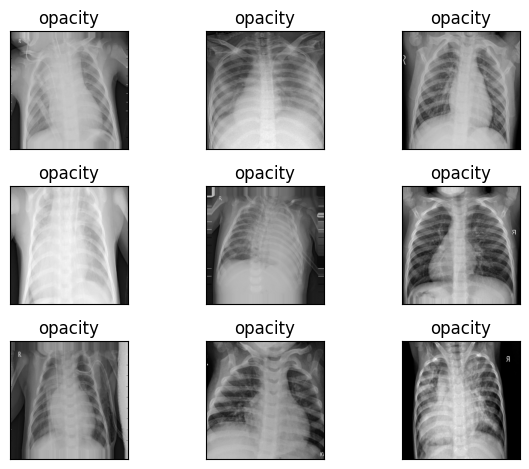

In [18]:
for i in range(9):
    ax = plt.subplot(3, 3, 1+i)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_title('%s'%(labels[int(batchY[i])]))
    plt.imshow(batchX[i][:,:,0], cmap=plt.get_cmap('gray'))

plt.tight_layout()
plt.savefig('chest_xray.png', dpi=300)

โค้ดนี้ใช้สำหรับแสดงภาพตัวอย่าง 9 ภาพจากชุดข้อมูลโดยจัดวางในรูปแบบ grid 3x3 พร้อมทั้งแสดงชื่อคลาสของแต่ละภาพในแต่ละ subplot โดยมีรายละเอียดดังนี้:


for i in range(9):
 • ใช้ loop เพื่อวน 9 ครั้ง (ค่าตั้งแต่ 0 ถึง 8) เพื่อเลือกภาพ 9 ภาพแรกจาก batch


ax = plt.subplot(3, 3, 1+i)
 • สร้าง subplot ในรูปแบบ 3 แถว x 3 คอลัมน์
 • ใช้ parameter 1+i เพื่อจัดลำดับ subplot แต่ละตัวตั้งแต่ 1 ถึง 9


ax.set_xticks([]) และ ax.set_yticks([])
 • กำหนดให้ไม่แสดงเครื่องหมาย tick บนแกน x และแกน y เพื่อให้ภาพดูสะอาดตา


ax.set_title('%s'%(labels[int(batchY[i])]))
 • ตั้งชื่อ title ให้กับ subplot โดยนำค่าจาก labels ตามป้ายกำกับของแต่ละภาพ
 • batchY[i] เป็น label ของภาพ (ตัวเลข) ซึ่งจะถูกแปลงเป็น int กับนำไปใช้ index แบบ list กับ labels เพื่อแสดงชื่อคลาส


plt.imshow(batchX[i][:, :, 0], cmap=plt.get_cmap('gray'))
 • แสดงภาพจาก batchX โดยเลือกภาพที่ตำแหน่ง i ใน batch
 • batchX[i][:, :, 0] หมายถึงการเลือก channel แรกของภาพ (โดยสมมุติว่าภาพถูกจัดเก็บในรูปแบบ 3 มิติ: ความสูง x ความกว้าง x channel)
 • cmap=plt.get_cmap('gray') ใช้ colormap แบบ grayscale ในการแสดงภาพ


plt.tight_layout()
 • ปรับ layout ของ subplots ให้มีการจัดวางที่เหมาะสมโดยไม่ให้ subplot ใดทับซ้อนกัน


plt.savefig('chest_xray.png', dpi=300)
 • บันทึก figure ที่สร้างขึ้นเป็นไฟล์ image ชื่อ "chest_xray.png" โดยใช้ความละเอียด 300 dpi


สรุปแล้ว โค้ดนี้จะสร้างภาพ grid 3x3 ซึ่งแสดงภาพตัวอย่างจาก batch พร้อมทั้งแสดงชื่อคลาสของแต่ละภาพและบันทึกผลลัพธ์เป็นไฟล์ PNG นั่นเองครับ

In [19]:
input_shape = (350, 350, 1)

# Input
inputs = tf.keras.Input(shape=input_shape)

# Feature Extraction
x = tf.keras.layers.Conv2D(32, (3, 3), activation='relu')(inputs)
x = tf.keras.layers.MaxPooling2D((2, 2))(x)

x = tf.keras.layers.Conv2D(32, (3, 3), activation='relu')(x)
x = tf.keras.layers.MaxPooling2D((2, 2))(x)

x = tf.keras.layers.Conv2D(64, (3, 3), activation='relu')(x)
x = tf.keras.layers.MaxPooling2D((2, 2))(x)

x = tf.keras.layers.Conv2D(64, (3, 3), activation='relu')(x)
x = tf.keras.layers.MaxPooling2D((2, 2))(x)

x = tf.keras.layers.Conv2D(128, (3, 3), activation='relu', padding='same', name='last_conv_layer')(x)

# Image Classification
x = tf.keras.layers.Flatten()(x)
x = tf.keras.layers.Dense(128, activation='relu')(x)
x = tf.keras.layers.Dense(64, activation='relu')(x)
outputs = tf.keras.layers.Dense(1, activation='sigmoid')(x)

# Model
model = tf.keras.Model(inputs=inputs, outputs=outputs)

โค้ดนี้สร้างโมเดลโครงข่ายประสาทเทียม (Convolutional Neural Network; CNN) สำหรับงานจำแนกภาพ โดยรายละเอียดของโค้ดมีดังนี้:


กำหนด input shape
 • input_shape = (350, 350, 1)
  – ระบุให้ข้อมูลอินพุตเป็นภาพขนาด 350x350 พิกเซล โดยมี 1 ช่องสัญญาณสี (grayscale)


ส่วน Input
 • inputs = tf.keras.Input(shape=input_shape)
  – กำหนดเลเยอร์อินพุตสำหรับโมเดล โดยรับข้อมูลตาม input_shape


ส่วน Feature Extraction (ส่วนที่ใช้สำหรับดึงคุณลักษณะของภาพ)
 • ใช้เลเยอร์ Conv2D และ MaxPooling2D หลายชุด
  – ชุดแรก:
   x = Conv2D(32, (3,3), activation='relu')(inputs)
   x = MaxPooling2D((2,2))(x)
  – ชุดที่สอง:
   x = Conv2D(32, (3,3), activation='relu')(x)
   x = MaxPooling2D((2,2))(x)
  – ชุดที่สาม:
   x = Conv2D(64, (3,3), activation='relu')(x)
   x = MaxPooling2D((2,2))(x)
  – ชุดที่สี่:
   x = Conv2D(64, (3,3), activation='relu')(x)
   x = MaxPooling2D((2,2))(x)
  – เลเยอร์ Convolution เพิ่มเติม
   x = Conv2D(128, (3,3), activation='relu', padding='same', name='last_conv_layer')(x)
    – เลเยอร์นี้มีชื่อว่า 'last_conv_layer' โดยมี padding แบบ 'same' เพื่อรักษาขนาดของ feature map เท่าเดิมตาม input และเพิ่มจำนวนฟิลเตอร์เป็น 128


ส่วน Image Classification (สำหรับจำแนกรูปภาพ)
 • Flatten
  – x = Flatten()(x)
   – ทำการยุบ tensor หลายมิติให้เป็น 1 มิติ
 • เลเยอร์ Dense เชื่อมต่อกัน
  – x = Dense(128, activation='relu')(x)
  – x = Dense(64, activation='relu')(x)
 • เลเยอร์ Output
  – outputs = Dense(1, activation='sigmoid')(x)
   – เลเยอร์นี้มีเพียง 1 หน่วย neuron พร้อม activation เป็น sigmoid จึงเหมาะสำหรับปัญหาการจำแนกประเภทแบบทวิภาค (binary classification)


สร้าง Model
 • model = tf.keras.Model(inputs=inputs, outputs=outputs)
  – กำหนดโมเดลโดยระบุอินพุตและเอาท์พุตที่ได้จากขั้นตอนก่อนหน้า


สรุป
โมเดลนี้เป็น CNN ที่มีหลายชั้น convolutional และ max pooling ในการดึงคุณลักษณะจากภาพ หลังจากนั้นใช้เลเยอร์ dense สองชั้นและเลเยอร์ sigmoid สำหรับการจำแนกประเภทแบบสองคลาส โมเดลนี้ถูกออกแบบมาสำหรับภาพขนาด 350x350 แบบ grayscale ซึ่งเหมาะสำหรับการจำแนกภาพในงานที่มีคลาสต่าง ๆ ที่ไม่มากนัก (เช่น การจำแนกโรคในภาพ X-ray)

In [20]:
# Compile the model
model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 350, 350, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 348, 348, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 174, 174, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 172, 172, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 86, 86, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 84, 84, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 42, 42, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 40, 40, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 20, 20, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ last_conv_layer (Conv2D)        │ (None, 20, 20, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 51200)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     6,553,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,700,897 (25.56 MB)

 Trainable params: 6,700,897 (25.56 MB)

 Non-trainable params: 0 (0.00 B)

คำสั่งด้านบนนี้มีไว้สำหรับการคอมไพล์โมเดลและแสดงข้อมูลสรุปของโมเดลที่สร้างขึ้น โดยมีรายละเอียดดังนี้:


model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
 • optimizer='adam'
  – ใช้ตัวปรับแต่ง (optimizer) แบบ Adam ซึ่งได้รับความนิยมในการฝึก deep learning โมเดลเนื่องจากมีการอัปเดตน้ำหนักที่มีประสิทธิภาพ
 • loss='binary_crossentropy'
  – กำหนดฟังก์ชัน Loss แบบ Binary Crossentropy ใช้สำหรับปัญหาจำแนกประเภทแบบทวิภาค (binary classification)
 • metrics=['accuracy']
  – ระบุให้วัดความแม่นยำ (accuracy) ในขณะทำการฝึกโมเดลและประเมินผล


model.summary()
 • คำสั่งนี้จะแสดงสรุปโครงสร้างของโมเดลที่สร้างไว้ ซึ่งรวมถึงข้อมูลเช่น
  – จำนวนเลเยอร์ที่ใช้
  – รูปแบบและรูปร่างของแต่ละเลเยอร์
  – จำนวน parameters ที่สามารถฝึก (trainable parameters)
  – จำนวน parameters ทั้งหมดในโมเดล


โดยสรุป โค้ดส่วนนี้ทำการคอมไพล์โมเดลด้วย optimizer, loss function และ metric ที่เหมาะสมสำหรับปัญหา binary classification และแสดงสรุปข้อมูลของโมเดลเพื่อให้สามารถตรวจสอบได้ว่าเลเยอร์แต่ละชั้นถูกสร้างขึ้นอย่างถูกต้องและมีจำนวนพารามิเตอร์ที่คาดไว้ครับ

In [21]:
ReduceLROnPlateau = tf.keras.callbacks.ReduceLROnPlateau

ReduceLROnPlateau ในที่นี้คือการอ้างอิงไปยัง callback ที่มีใน tf.keras.callbacks เพื่อลดอัตราการเรียนรู้ (learning rate) เมื่อประสิทธิภาพของโมเดลในการฝึกไม่ดีขึ้นตามที่คาดหวังไว้
โดยทั่วไป การใช้งาน ReduceLROnPlateau จะช่วยให้โมเดลสามารถปรับลด learning rate เมื่อ loss (หรือ metric ที่กำหนด) ไม่ปรับปรุงในช่วงเวลาหนึ่ง วิธีนี้ช่วยให้โมเดลสามารถเข้าใกล้จุด minimum ได้ดีขึ้นในระหว่างการฝึก
ตัวอย่างการกำหนดค่าพารามิเตอร์ที่พบบ่อย ได้แก่
• monitor: ระบุ metric ที่จะตรวจสอบ (เช่น 'val_loss')
 • factor: ค่าที่ใช้ลด learning rate เช่น 0.1 (หมายความว่า learning rate จะถูกคูณด้วย 0.1 หากเงื่อนไขถูกกระทำ)
 • patience: จำนวน epochs ที่รอให้ metric ไม่พัฒนา ก่อนที่จะลด learning rate
 • verbose: ระดับข้อความที่จะแสดงออกมาในขณะลด learning rate (0 เงียบ, 1 แสดงข้อความ)
 • min_lr: ค่า learning rate ต่ำสุดที่อนุญาต
ตัวอย่างการใช้งานจริง:
reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.1, patience=3, verbose=1, min_lr=1e-6)
ในโค้ดของคุณ การระบุ
 ReduceLROnPlateau = tf.keras.callbacks.ReduceLROnPlateau
คือการสร้าง alias ให้กับ callback นี้ โดยสามารถนำไปใช้งานในระหว่างการฝึกโมเดลผ่าน model.fit ได้ใน parameter callbacks เช่น
model.fit(..., callbacks=[ReduceLROnPlateau(monitor='val_loss', factor=0.1, patience=3)])
สรุปคือ โค้ดบรรทัดนี้คือการเข้าถึง callback ที่ TensorFlow Keras จัดเตรียมไว้เพื่อช่วยลด learning rate อัตโนมัติตามประสิทธิภาพของโมเดลในแต่ละ epoch เมื่อมี stagnation ในการพัฒนา loss นั่นเอง

In [22]:
learning_rate_reduction = ReduceLROnPlateau(monitor='val_loss', patience = 2, verbose=1,factor=0.1, min_lr=0.000001)
callbacks_list = [learning_rate_reduction]

โค้ดนี้สร้าง callback เพื่อลดค่า learning rate ระหว่างการฝึกโมเดลโดยอัตโนมัติเมื่อ metric ที่กำหนด (ในที่นี้คือ 'val_loss') ไม่ปรับปรุงตามที่ต้องการในช่วง epochs ที่กำหนด โดยมีรายละเอียดดังนี้:


learning_rate_reduction = ReduceLROnPlateau(monitor='val_loss',
  - monitor='val_loss':
   – ระบุให้ตรวจสอบค่า validation loss
   – หาก 'val_loss' ไม่ดีขึ้นตามที่คาดหวังไว้ คำสั่งนี้จะทำงานเพื่อลด learning rate


patience = 2
  - ระบุจำนวน epochs ที่รอให้ 'val_loss' ไม่ดีขึ้นก่อนที่จะลด learning rate
  - ในที่นี้ ถ้า 'val_loss' ไม่ลดลงภายใน 2 epochs จะลด learning rate


verbose = 1
  - กำหนดระดับการแสดงข้อความแจ้งเตือน
  - เมื่อมีการลด learning rate จะมีข้อความแสดงรายละเอียดออกมา


factor = 0.1
  - เป็นตัวคูณที่ใช้ลด learning rate
  - เมื่อทำการลดค่า learning rate ค่าใหม่จะเป็น lr × 0.1


min_lr = 0.000001
  - กำหนดค่า learning rate ขั้นต่ำที่ไม่ให้ลดต่ำลงเกินค่านี้
  - เพื่อป้องกันไม่ให้ค่า learning rate ลดลงจนเกินไป


callbacks_list = [learning_rate_reduction]
  - สร้างลิสต์ของ callbacks ซึ่งสามารถส่งให้กับ model.fit() ในขณะที่ฝึกโมเดลได้
  - ทำให้ callback ที่ลด learning rate นี้ทำงานร่วมกับกระบวนการฝึกโมเดล


สรุป
โค้ดนี้ช่วยให้การฝึกโมเดลมีประสิทธิภาพมากขึ้นโดยการปรับลด learning rate โดยอัตโนมัติเมื่อ validation loss ไม่ดีขึ้นหลังจากรอ epochs ที่กำหนดไว้ ซึ่งจะช่วยให้โมเดลปรับค่า parameter เร็วและแม่นยำยิ่งขึ้นในขั้นตอนการฝึกโมเดลครับ

In [23]:
# Train the model
epochs = 30
history = model.fit(
    train_generator,
    callbacks=callbacks_list,
    steps_per_epoch=train_generator.samples // batch_size,
    epochs=epochs,
    validation_data=validation_generator,
    validation_steps=validation_generator.samples // batch_size,
    class_weight=cw # Apply class weights to handle imbalance
)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/30
131/131 ━━━━━━━━━━━━━━━━━━━━ 117s 806ms/step - accuracy: 0.5684 - loss: 0.6338 - val_accuracy: 0.9209 - val_loss: 0.2547 - learning_rate: 0.0010
Epoch 2/30
131/131 ━━━━━━━━━━━━━━━━━━━━ 97s 538ms/step - accuracy: 0.8960 - loss: 0.2671 - val_accuracy: 0.9307 - val_loss: 0.1926 - learning_rate: 0.0010
Epoch 3/30
131/131 ━━━━━━━━━━━━━━━━━━━━ 71s 541ms/step - accuracy: 0.9197 - loss: 0.2191 - val_accuracy: 0.8994 - val_loss: 0.2289 - learning_rate: 0.0010
Epoch 4/30
131/131 ━━━━━━━━━━━━━━━━━━━━ 69s 530ms/step - accuracy: 0.9167 - loss: 0.2057 - val_accuracy: 0.9502 - val_loss: 0.1316 - learning_rate: 0.0010
Epoch 5/30
131/131 ━━━━━━━━━━━━━━━━━━━━ 92s 611ms/step - accuracy: 0.9371 - loss: 0.1592 - val_accuracy: 0.9424 - val_loss: 0.2125 - learning_rate: 0.0010
Epoch 6/30
131/131 ━━━━━━━━━━━━━━━━━━━━ 79s 586ms/step - accuracy: 0.9108 - loss: 0.2268 - val_accuracy: 0.9561 - val_loss: 0.1205 - learning_rate: 0.0010
Epoch 7/30
131/131 ━━━━━━━━━━━━━━━━━━━━ 142s 1s/step - accuracy: 0.93

โค้ดนี้เป็นการสั่งฝึก (train) โมเดลที่สร้างไว้ โดยใช้ข้อมูลจากตัวสร้างข้อมูล (data generators) ทั้งสำหรับชุดฝึก (train_generator) และชุดทดสอบ (validation_generator) พร้อมทั้งมีการใช้งาน callbacks ต่างๆ และใช้ class weights ในการแก้ปัญหาความไม่สมดุลของคลาส (class imbalance) รายละเอียดของโค้ดมีดังนี้:


epochs = 30
 • กำหนดจำนวนรอบ (epochs) ที่จะฝึกโมเดลทั้งหมด 30 รอบ


history = model.fit(...)
 • ใช้คำสั่ง fit() เพื่อฝึกโมเดล โดยส่งพารามิเตอร์ต่าง ๆ ดังนี้


- train_generator:
   • เป็นตัวสร้างข้อมูลฝึก (training data generator) ที่ใช้ป้อนข้อมูลภาพและป้ายกำกับ (labels) ให้กับโมเดลแบบ batch-by-batch
- callbacks=callbacks_list:
   • ส่งลิสต์ของ callbacks ที่จะเรียกใช้ระหว่างการฝึก
   • ในที่นี้ callback ที่ส่งไปคือ learning_rate_reduction ซึ่งจะปรับลด learning rate อัตโนมัติหาก 'val_loss' ไม่ดีขึ้น
- steps_per_epoch=train_generator.samples // batch_size:
   • ระบุจำนวนขั้นตอน (steps) ที่จะดำเนินในแต่ละ epoch
   • จำนวนนี้คำนวณโดยหารจำนวนตัวอย่างในชุดฝึก (train_generator.samples) ด้วยขนาดของ batch (batch_size)
- epochs=epochs:
   • จำนวน epochs ที่ระบุไว้คือ 30
- validation_data=validation_generator:
   • กำหนดชุดข้อมูล validation ที่ใช้ประเมินผลโมเดลในแต่ละ epoch
- validation_steps=validation_generator.samples // batch_size:
   • ระบุจำนวนขั้นตอนของ validation ต่อแต่ละ epoch โดยคำนวณเช่นเดียวกับ training
- class_weight=cw:
   • ใช้ class weights ซึ่งเป็นพารามิเตอร์ cw ที่กำหนดไว้ล่วงหน้า
   • เพื่อจัดการกับข้อมูลที่มีการกระจายคลาสไม่สมดุล โดยให้น้ำหนักกับคลาสต่าง ๆ ตามที่ระบุ
สรุป
โค้ดนี้เป็นการฝึกโมเดลด้วยข้อมูลจาก generators และมีการกำหนด callbacks รวมถึง class weights เพื่อเพิ่มประสิทธิภาพในการแก้ปัญหาความไม่สมดุลของข้อมูล โดยฝึกเป็นเวลา 30 epochs และมีการระบุจำนวน steps สำหรับ training และ validation ตามขนาดของ batch ที่กำหนดไว้ครับ

In [24]:
loss, accuracy = model.evaluate(test_generator, steps=test_generator.samples // batch_size)

print(f"Test Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy:.4f}")

19/19 ━━━━━━━━━━━━━━━━━━━━ 7s 337ms/step - accuracy: 0.9007 - loss: 0.4981
Test Loss: 0.3422
Test Accuracy: 0.9227


โค้ดนี้ใช้สำหรับประเมินผลโมเดลที่ฝึกเสร็จแล้วบนชุดข้อมูลทดสอบ (test_generator) โดยรายละเอียดมีดังนี้:


loss, accuracy = model.evaluate(test_generator, steps=test_generator.samples // batch_size)
 • model.evaluate() จะคำนวณค่าความสูญเสีย (loss) และความแม่นยำ (accuracy) บนชุดข้อมูลทดสอบ
 • steps=test_generator.samples // batch_size กำหนดจำนวนขั้นตอนในการประเมิน โดยคำนวณจากจำนวนตัวอย่างในชุดทดสอบหารด้วยขนาดของ batch
  – ทำให้การประเมินผลทำเป็น batch แต่ละ batch เพื่อความมีประสิทธิภาพในการประมวลผล


print(f"Test Loss: {loss:.4f}")
 • แสดงค่าความสูญเสียที่ได้จากการประเมิน โดยปัดตัวเลขให้แสดง 4 ตำแหน่งทศนิยม


print(f"Test Accuracy: {accuracy:.4f}")
 • แสดงค่าความแม่นยำที่ได้จากการประเมินโดยใช้รูปแบบเดียวกัน


สรุป
โค้ดส่วนนี้ประเมินโมเดลที่ฝึกเสร็จแล้วด้วยชุดข้อมูลทดสอบและแสดงผลค่าความสูญเสียและความแม่นยำที่ได้จากการทดสอบ ซึ่งช่วยให้เราทราบถึงประสิทธิภาพของโมเดลบนข้อมูลที่ยังไม่เคยเห็นมาก่อนครับ

In [25]:
import plotly
import plotly.graph_objs as go
import plotly.figure_factory as ff
import plotly.express as px
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.metrics import roc_curve, auc

import pandas as pd

โค้ดบรรทัดนี้เป็นการนำเข้า (import) ไลบรารีและโมดูลต่าง ๆ ที่จำเป็นสำหรับการสร้างกราฟและวิเคราะห์ประสิทธิภาพของโมเดลในขั้นตอนการประเมินผล โดยรายละเอียดของแต่ละส่วนมีดังนี้:


import plotly
 • นำเข้าไลบรารี Plotly ที่ใช้สำหรับการสร้าง interactive plots และ visualization ที่มีความยืดหยุ่นสูง


import plotly.graph_objs as go
 • นำเข้ามอดูล graph objects ของ Plotly โดยใช้ alias "go"
 • ช่วยให้คุณสามารถสร้างและปรับแต่ง object ของกราฟ เช่น Scatter, Bar, Layout เป็นต้น


import plotly.figure_factory as ff
 • นำเข้ามอดูล figure factory ซึ่งมีฟังก์ชันสำเร็จรูปสำหรับการสร้างกราฟหรือเทคนิค visualization ที่ซับซ้อนได้ง่ายขึ้น เช่น การสร้าง heatmap, distplot เป็นต้น


import plotly.express as px
 • นำเข้ามอดูล Plotly Express ซึ่งเป็น API ระดับสูงสำหรับการสร้างกราฟที่มีการตั้งค่าพื้นฐานอย่างรวดเร็วและง่ายต่อการใช้งาน


from sklearn.metrics import confusion_matrix
 • นำเข้าฟังก์ชัน confusion_matrix จาก scikit-learn ซึ่งใช้สำหรับสร้าง confusion matrix ของโมเดล (แสดงจำนวนการทำนายที่ถูกต้องและผิดพลาดในแต่ละคลาส)


from sklearn.metrics import classification_report
 • นำเข้าฟังก์ชัน classification_report ซึ่งให้รายงานประเมินผลของโมเดลในเรื่อง precision, recall, f1-score และ support สำหรับแต่ละคลาส


from sklearn.metrics import roc_curve, auc
 • นำเข้าฟังก์ชัน roc_curve สำหรับสร้างค่า ROC curve (Receiver Operating Characteristic curve)
 • นำเข้าฟังก์ชัน auc เพื่อคำนวณค่า AUC (Area Under the Curve) ซึ่งเป็นการวัดประสิทธิภาพการแยกประเภทของโมเดล


import pandas as pd
 • นำเข้าไลบรารี Pandas โดยใช้นามแฝง pd
 • ใช้สำหรับการจัดการและวิเคราะห์ข้อมูลในรูปแบบ DataFrame ซึ่งเหมาะสำหรับงาน preprocessing, data cleaning และการแสดงผลข้อมูล


สรุป
โค้ดนี้เตรียมความพร้อมของเครื่องมือสำหรับการสร้าง visualization การวิเคราะห์ประสิทธิภาพโมเดล และการจัดการข้อมูล เพื่อให้สามารถนำเสนอผลการทดสอบของโมเดลทั้งในรูปแบบของกราฟและรายงานทางสถิติได้อย่างมีประสิทธิภาพครับ

In [27]:
h1 = go.Scatter(y=history.history['loss'],
                    mode="lines",
                    line=dict(
                        width=2,
                        color='blue'),
                        name="loss"
                   )
h2 = go.Scatter(y=history.history['val_loss'],
                    mode="lines",
                    line=dict(
                        width=2,
                        color='red'),
                        name="val_loss"
                   )

data = [h1,h2]
layout1 = go.Layout(title='Loss',
                   xaxis=dict(title='epochs'),
                   yaxis=dict(title=''))
fig1 = go.Figure(data, layout=layout1)
plotly.offline.iplot(fig1)

โค้ดนี้ใช้ Plotly ในการสร้างกราฟแสดงการเปลี่ยนแปลงของค่า loss ในระหว่างการฝึกโมเดล (training) โดยเปรียบเทียบระหว่าง loss ของชุดฝึก (loss) และชุด validation (val_loss) ดังรายละเอียดต่อไปนี้:


h1 = go.Scatter(...)
 • สร้าง trace สำหรับกราฟเส้น (line plot) ของค่า loss ในชุดฝึก
 • y=history.history['loss']: ใช้ข้อมูลจาก dictionary history ที่บันทึกค่า loss ในแต่ละ epoch
 • mode="lines": ให้แสดงผลเป็นเส้นต่อเนื่อง
 • line=dict(width=2, color='blue'): กำหนดความหนา 2 หน่วยและสีของเส้นเป็นสีน้ำเงิน
 • name="loss": ตั้งชื่อ trace นี้ว่า "loss"


h2 = go.Scatter(...)
 • สร้าง trace สำหรับกราฟเส้นแสดงค่า validation loss
 • y=history.history['val_loss']: ใช้ข้อมูลจาก dictionary history สำหรับค่า validation loss
 • line มีการกำหนดความหนา 2 หน่วยและสีเป็นสีแดง
 • name="val_loss": ตั้งชื่อ trace นี้ว่า "val_loss"


data = [h1, h2]
 • รวม trace ทั้งสองเข้าด้วยกันในลิสต์ data ซึ่งจะถูกนำไปจุดร่วมใน Figure ที่จะสร้าง


layout1 = go.Layout(...)
 • กำหนด layout ของกราฟ
 • title='Loss': กำหนดหัวข้อกราฟเป็น "Loss"
 • xaxis=dict(title='epochs'): ตั้งชื่อแกน x ว่า "epochs"
 • yaxis=dict(title=''): กำหนดชื่อแกน y (ว่างในที่นี้ ซึ่งอาจปรับเปลี่ยนให้เหมาะสมตามข้อมูล)


fig1 = go.Figure(data, layout=layout1)
 • สร้าง Figure โดยใช้ข้อมูล (data) และกำหนด layout จาก layout1


plotly.offline.iplot(fig1)
 • แสดงกราฟในรูปแบบแบบ interactive โดยใช้ฟังก์ชัน offline.iplot ซึ่งมักใช้ใน environment เช่น Jupyter Notebook


สรุป
โค้ดนี้ช่วยให้คุณสามารถตรวจสอบและเปรียบเทียบค่า loss ของการฝึกและ validation ได้ในแต่ละ epoch ด้วยกราฟเส้นที่ชัดเจน โดยใช้ Plotly ซึ่งสามารถโต้ตอบและซูมเข้าออกได้อย่างสะดวกในระหว่างการวิเคราะห์ประสิทธิภาพโมเดลค่ะ

In [28]:
h1 = go.Scatter(y=history.history['accuracy'],
                    mode="lines", line=dict(
                    width=2,
                    color='blue'),
                    name="acc"
                   )
h2 = go.Scatter(y=history.history['val_accuracy'],
                    mode="lines", line=dict(
                    width=2,
                    color='red'),
                    name="val_acc"
                   )

data = [h1,h2]
layout1 = go.Layout(title='Accuracy',
                   xaxis=dict(title='epochs'),
                   yaxis=dict(title=''))
fig1 = go.Figure(data = da

SyntaxError: incomplete input (ipython-input-3092372921.py, line 18)

โค้ดนี้มีวัตถุประสงค์เพื่อสร้างกราฟแสดงผลความแม่นยำ (accuracy) ของการฝึกโมเดล (training) และ validation accuracy โดยใช้ Plotly ในรูปแบบ interactive plot รายละเอียดมีดังนี้:

h1 = go.Scatter(...):
 • สร้าง trace สำหรับกราฟเส้นแสดงค่าความแม่นยำในชุดฝึก
 • y=history.history['accuracy']: ใช้ข้อมูลความแม่นยำในแต่ละ epoch จาก history ที่ได้บันทึกระหว่างการฝึก
 • mode="lines": กำหนดให้แสดงผลเป็นเส้นต่อเนื่อง
 • line=dict(width=2, color='blue'): กำหนดความหนาของเส้นเป็น 2 และสีเป็นสีน้ำเงิน
 • name="acc": ตั้งชื่อ trace ว่า "acc"

h2 = go.Scatter(...):
 • สร้าง trace สำหรับกราฟเส้นแสดงค่าความแม่นยำของ validation
 • y=history.history['val_accuracy']: ใช้ข้อมูล validation accuracy จาก history
 • กำหนดให้แบบเส้น โดยมีความหนา 2 และสีเป็นสีแดง
 • name="val_acc": ตั้งชื่อ trace ว่า "val_acc"

data = [h1, h2]:
 • รวม traces ทั้งสอง (training accuracy และ validation accuracy) ไว้ในลิสต์ data เพื่อนำไปใช้ใน Figure

layout1 = go.Layout(...):
 • กำหนดลักษณะการจัดวางของกราฟ (layout)
 • title='Accuracy': ตั้งชื่อหัวข้อกราฟว่า "Accuracy"
 • xaxis=dict(title='epochs'): กำหนดชื่อแกน x ว่า "epochs"
 • yaxis=dict(title=''): ชื่อแกน y ไม่ได้ระบุ (คุณสามารถเพิ่มรายละเอียดได้ตามต้องการ)

fig1 = go.Figure(data = da... :
 • โค้ดนี้ดูเหมือนจะถูกตัดค้างไว้ เนื่องจากชื่อ parameter ที่ควรจะส่งเข้าไปน่าจะเป็น data (เช่น fig1 = go.Figure(data=data, layout=layout1))
 • หลังจากสร้าง Figure แล้ว คุณสามารถแสดงกราฟโดยใช้คำสั่ง plotly.offline.iplot(fig1) หากทำงานใน Jupyter Notebook หรือวิธีอื่นๆ ตาม environment ที่ใช้งาน

สรุป
โค้ดนี้ช่วยให้คุณสามารถดูการเปลี่ยนแปลงของความแม่นยำระหว่างการฝึกโมเดลและ validation ตาม epochs ได้อย่าง interactive โดยใช้ Plotly
  หมายเหตุ: ตรวจสอบให้แน่ใจว่ามีการแก้ไขหรือเติมส่วนที่ขาดหายไปในบรรทัดสุดท้ายของโค้ด (เช่น แทนที่ "da" ด้วย "data, layout=layout1") เพื่อให้โค้ดทำงานได้ถูกต้องครับ

In [29]:
predicted_classes = (model.predict(test_generator, verbose=1) > 0.5).astype("int32")[:,0]

20/20 ━━━━━━━━━━━━━━━━━━━━ 5s 211ms/step


โค้ดนี้มีวัตถุประสงค์เพื่อคาดการณ์คลาสของข้อมูลชุดทดสอบโดยใช้โมเดลที่ฝึกแล้วและแปลงผลลัพธ์ที่ได้ให้อยู่ในรูปแบบของตัวเลขดังนี้:


model.predict(test_generator, verbose=1)
 • โมเดลจะทำการคาดการณ์ (predict) โดยใช้ข้อมูลจาก test_generator
 • ผลลัพธ์ที่ได้จะเป็นอาร์เรย์ของค่าความน่าจะเป็น (probabilities) สำหรับแต่ละตัวอย่างในชุดทดสอบ
 • verbose=1 ช่วยให้แสดง progress ของการคาดการณ์ในขณะที่รันอยู่


( ... > 0.5)
 • เปรียบเทียบค่าความน่าจะเป็นที่ได้กับค่า 0.5
 • เมื่อค่าความน่าจะเป็นมากกว่า 0.5 ผลลัพธ์จะเป็น True (แทนคลาสบวก) และหากน้อยกว่าจะเป็น False (แทนคลาสลบ)
 • การเปรียบเทียบนี้ใช้สำหรับแปลงค่าความน่าจะเป็นให้เป็นการคาดการณ์เป็นคลาส (0 หรือ 1)


.astype("int32")
 • แปลงผลลัพธ์ที่เป็น Boolean (True/False) ให้เป็นจำนวนเต็ม (int32) โดยที่ True จะถูกแปลงเป็น 1 และ False เป็น 0


[:,0]
 • เนื่องจาก model.predict() อาจคืนค่าในรูปแบบของ array 2 มิติ (ซึ่งแต่ละ row อาจมีเพียงหนึ่งค่า)
 • เครื่องหมาย [:,0] ใช้เพื่อเข้าถึงคอลัมน์แรกของผลลัพธ์ ซึ่งคือค่า predicted class สำหรับแต่ละตัวอย่าง


สรุป
โค้ดนี้ทำงานดังนี้:

ใช้โมเดลในการคาดการณ์ความน่าจะเป็นของแต่ละตัวอย่างในชุดทดสอบ
เปรียบเทียบกับค่า 0.5 เพื่อแปลงความน่าจะเป็นให้เป็นคลาส (0 หรือ 1)
แปลงผลลัพธ์เป็นตัวเลขในรูปแบบ int32
สุดท้าย ตัดเอาคอลัมน์แรกออกมาเป็นผลลัพธ์ของ predicted classes ในแต่ละตัวอย่าง

ด้วยวิธีนี้ คุณจะได้อาร์เรย์ที่มีค่าเป็น 0 หรือ 1 แสดงถึงการคาดการณ์คลาสของแต่ละตัวอย่างในชุดทดสอบครับ

In [30]:
predicted_classes[:10]

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0], dtype=int32)

โค้ดนี้ใช้สำหรับเข้าถึงและแสดงค่าที่อยู่ในตำแหน่งแรกๆ ของอาร์เรย์ predicted_classes โดยเฉพาะส่วนย่อยของอาร์เรย์ที่มี index 0 ถึง 9 (รวมทั้งหมด 10 ค่า) ซึ่งสามารถอธิบายได้ดังนี้:
• predicted_classes คืออาร์เรย์ที่ได้จากการคาดการณ์ (prediction) ของโมเดล
• [:10] คือการใช้ slicing เพื่อเลือกเฉพาะสมาชิกตัวแรก 10 ตัวจากอาร์เรย์นั้น
ผลลัพธ์ที่ได้คือรายการของการคาดการณ์คลาส (เช่น 0 หรือ 1) สำหรับตัวอย่าง 10 ตัวแรกในชุดข้อมูลทดสอบครับ

In [31]:
test_generator.classes[:10]

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0], dtype=int32)

โค้ดนี้ใช้สำหรับเข้าถึงและแสดงค่าจริง (ground truth) ของคลาสในชุดข้อมูลทดสอบที่ถูกจัดเก็บใน test_generator โดยเฉพาะส่วนย่อยที่มี index 0 ถึง 9 (10 ตัวแรก) รายละเอียดมีดังนี้:
• test_generator.classes คือ attribute ที่เก็บค่าป้ายกำกับ (labels) ของแต่ละตัวอย่างในชุดข้อมูลทดสอบที่สร้างขึ้นจาก generator
• [:10] ใช้ slicing เพื่อเลือกเฉพาะสมาชิกตัวแรก 10 ตัวจากอาร์เรย์ของคลาส
ผลลัพธ์ที่ได้จะเป็นอาร์เรย์ที่มีค่าเป็นหมายเลข เช่น 0 หรือ 1 (ขึ้นอยู่กับการจัดกลุ่มของข้อมูล) ที่เป็นป้ายของคลาสจริงสำหรับตัวอย่าง 10 ตัวแรกในชุดข้อมูลทดสอบครับ

In [32]:
def cm_plot(cm, labels):
    x = labels
    y = labels

    z_text = [[str(y) for y in x] for x in cm]
    fig = ff.create_annotated_heatmap(cm, x=x, y=y, annotation_text=z_text, colorscale='blues')

    fig.update_layout(title_text='Confusion Matrix')

    fig.add_annotation(dict(font=dict(color="black",size=13),
                            x=0.5,
                            y=-0.15,
                            showarrow=False,
                            text="Predicted Value",
                            xref="paper",
                            yref="paper"
                           ))

    fig.add_annotation(dict(font=dict(color="black",size=13),
                            x=-0.20,
                            y=0.5,
                            showarrow=False,
                            text="Real Value",
                            textangle=-90,
                            xref="paper",
                            yref="paper"
                           ))

    fig.update_layout(margin=dict(t=50, l=200))
    fig['layout']['yaxis']['autorange'] = "reversed"

    fig['data'][0]['showscale'] = True
    fig.show()

ฟังก์ชัน cm_plot นี้มีไว้สำหรับวาด heatmap ของ Confusion Matrix โดยใช้ไลบรารี Plotly (ส่วน ff มาจาก plotly.figure_factory) ซึ่งรายละเอียดของแต่ละส่วนในฟังก์ชันมีดังนี้:


รับ parameter
 • cm: ตัวแปรในรูปแบบ array (หรือ list) ที่มีข้อมูล confusion matrix
 • labels: รายการของชื่อ label (หรือ class names) ที่ใช้สำหรับแกน x และ y


กำหนดแกน x และ y
 • x = labels และ y = labels คือการกำหนดให้ชื่อ label ทั้งสองแกนเหมือนกัน


สร้าง annotation text
 • z_text สร้าง annotation สำหรับแต่ละ cell โดยการแปลงค่าภายในแต่ละ cell ของ cm ให้เป็น string แล้วเก็บไว้ใน list ที่เป็นแบบ 2 มิติ
 • ใช้ list comprehension สองชั้นเพื่อวนลูปแต่ละแถวและแต่ละค่าภายในแถว ซึ่งจะแสดงเป็นตัวเลขในแต่ละ cell ของ heatmap


สร้าง heatmap พร้อม annotation
 • ใช้ ff.create_annotated_heatmap โดยส่งค่า cm, x, y, annotation_text=z_text และกำหนดให้ใช้ colorscale เป็น 'blues'
 • ฟังก์ชันนี้จะสร้าง heatmap ที่มี annotation (แสดงตัวเลข) สำหรับแต่ละ cell


ปรับแต่ง layout ของกราฟ
 • fig.update_layout(title_text='Confusion Matrix'): กำหนดหัวข้อกราฟเป็น "Confusion Matrix"
 • fig.add_annotation: ใช้ในการเพิ่มข้อความบอกแกน x และแกน y โดยอธิบายว่า "Predicted Value" อยู่ด้านล่างและ "Real Value" อยู่ด้านซ้าย (โดยใช้ textangle=-90)
 • fig.update_layout(margin=dict(t=50, l=200)): ปรับขอบของกราฟให้มี margin ที่เหมาะสม


ปรับแกน y
 • fig['layout']['yaxis']['autorange'] = "reversed": ทำให้แกน y ถูกกลับด้าน (เริ่มจากค่าสูงสุดไปต่ำสุด) ซึ่งมักเป็นมาตรฐานในการแสดง confusion matrix


เปิดแสดง scale ของสี
 • fig['data'][0]['showscale'] = True: ทำให้แถบสี (color scale) ปรากฎอยู่ในกราฟ


แสดงกราฟ
 • fig.show(): แสดงผลกราฟ heatmap ที่ได้


สรุป
ฟังก์ชันนี้มีไว้เพื่อแสดง confusion matrix ด้วย heatmap พร้อมทั้งการแสดงตัวเลขในแต่ละ cell เพื่อให้เห็นค่าแต่ละ cell ของ confusion matrix พร้อมคำอธิบายในแกน x (Predicted Value) และแกน y (Real Value)
คุณสามารถเรียกใช้งานฟังก์ชันนี้โดยส่ง confusion matrix (cm) ที่คุณคำนวณจากผลการทำนายของโมเดลและรายชื่อ label ที่เหมาะสมเป็น parameter ครับ

In [33]:
Counter(test_generator.classes)

Counter({np.int32(0): 234, np.int32(1): 390})

โค้ด Counter(test_generator.classes) ทำหน้าที่นับจำนวนตัวอย่างในแต่ละคลาสของชุดข้อมูลที่สร้างโดย test_generator โดยใช้ฟังก์ชัน Counter จากไลบรารี collections ของ Python ซึ่งจะให้ผลลัพธ์เป็น dictionary-like object ที่ระบุจำนวนของแต่ละคลาสใน test_generator.classes
รายละเอียดเพิ่มเติม:
 • test_generator.classes มักจะเก็บป้ายกำกับ (labels) ของแต่ละตัวอย่างในชุดข้อมูลทดสอบที่ถูกสร้างโดย generator
 • Counter() จะวนลูปผ่าน test_generator.classes นับจำนวนครั้งที่แต่ละ label ปรากฏขึ้น
 • ผลลัพธ์ที่ได้จะอยู่ในรูปแบบ {label: count, ...} ตัวอย่างเช่น {0: 50, 1: 70} หมายความว่ามี 50 ตัวอย่างในคลาส 0 และ 70 ตัวอย่างในคลาส 1
ด้วยวิธีนี้คุณสามารถตรวจสอบ distribution หรือความสมดุลของคลาสในชุดข้อมูลทดสอบได้อย่างง่ายดายครับ

In [34]:
cm = confusion_matrix(test_generator.classes, predicted_classes)
cm

array([[197,  37],
       [ 10, 380]])

คำสั่งนี้ใช้คำนวณ confusion matrix โดยเปรียบเทียบค่าจริง (ground truth) จาก test_generator.classes กับค่าที่โมเดลคาดการณ์ไว้ (predicted_classes) ซึ่งสร้างโดยใช้ฟังก์ชัน confusion_matrix จากไลบรารี sklearn.metrics
รายละเอียด:

เรามีค่าจริงของคลาสอยู่ใน test_generator.classes และค่าที่ทำนายโดยโมเดลอยู่ในตัวแปร predicted_classes
เมื่อเราเรียก confusion_matrix(test_generator.classes, predicted_classes) ระบบจะเปรียบเทียบระหว่างค่าสองชุดนี้ เมื่อมีการทำนายถูกและผิดออกมา โดยผลลัพธ์ที่ได้จะเป็นอาร์เรย์ (numpy array) ที่มีรูปแบบเป็น matrix
ใน matrix นี้ แถว (rows) จะแทนค่าจริง (actual class) และคอลัมน์ (columns) จะแทนค่าที่ทำนาย (predicted class)
ค่าต่างๆ ใน matrix จะบอกจำนวนตัวอย่างที่อยู่ในแต่ละช่องของการเปรียบเทียบ เช่น จำนวนของตัวอย่างที่เป็นคลาส 0 ที่ถูกทำนายเป็นคลาส 0, จำนวนที่เป็นคลาส 0 ที่ทำนายผิดเป็นคลาส 1 เป็นต้น

เมื่อรันคำสั่งนี้แล้วตัวแปร cm จะเก็บ confusion matrix ที่สามารถนำไปวิเคราะห์ประสิทธิภาพของโมเดลได้ต่อไปครับ

In [35]:
cm_plot(cm, labels)

คำสั่ง cm_plot(cm, labels) ใช้เพื่อเรียกใช้งานฟังก์ชัน cm_plot ที่เราได้สร้างไว้ โดยส่งข้อมูล confusion matrix (cm) และรายชื่อของป้ายกำกับ (labels) เข้าไปในฟังก์ชันนี้ ดังนี้:


cm คือ confusion matrix ที่คำนวณได้จากฟังก์ชัน confusion_matrix เปรียบเทียบค่าจริง (test_generator.classes) กับค่าที่โมเดลคาดการณ์ไว้ (predicted_classes)


labels คือรายชื่อของป้ายกำกับแต่ละคลาส (เช่น ถ้ามี 2 คลาสอาจจะเป็น ["class 0", "class 1"]) ซึ่งจะถูกนำไปใช้กำหนดชื่อแกน x และ y ใน heatmap


โดยฟังก์ชัน cm_plot จะสร้างกราฟ heatmap ของ confusion matrix โดย:
 • ใช้ colorscale 'blues' เพื่อให้กราฟมีสีที่มีเฉดที่แตกต่างกันตามค่าของแต่ละ cell
 • ใส่ annotation (ตัวเลขในแต่ละ cell) เพื่อแสดงจำนวนของแต่ละ cell
 • กำหนดหัวข้อของกราฟและใส่ข้อความสำหรับระบุแกน Predicted Value (แกน x) และ Real Value (แกน y)
 • ปรับแกน y ให้แสดงโดยกลับด้าน (reversed) เพื่อให้เข้ากับมาตรฐานการนำเสนอ confusion matrix
สรุปคือ เมื่อรันคำสั่งนี้ cm_plot(cm, labels) จะทำให้ระบบแสดงกราฟ heatmap ของ confusion matrix พร้อมรายละเอียดของการทำนายโมเดลในแต่ละคลาส ซึ่งช่วยให้เราเห็นภาพรวมของประสิทธิภาพโมเดลได้อย่างชัดเจนครับ

In [36]:
report = classification_report(test_generator.classes, predicted_classes, target_names=labels, digits=4)

print(report)

              precision    recall  f1-score   support

      normal     0.9517    0.8419    0.8934       234
     opacity     0.9113    0.9744    0.9418       390

    accuracy                         0.9247       624
   macro avg     0.9315    0.9081    0.9176       624
weighted avg     0.9264    0.9247    0.9236       624



คำสั่งนี้ใช้ในการประเมินประสิทธิภาพของโมเดลจดจำแบบจำแนกประเภท (classification) โดยใช้ฟังก์ชัน classification_report จากไลบรารี sklearn.metrics มีรายละเอียดดังนี้:


target_names=labels
 • กำหนดชื่อคลาสให้กับแต่ละ label ซึ่งจะปรากฏในรายงานผล (เช่น ["class 0", "class 1"])


digits=4
 • กำหนดจำนวนทศนิยมที่ต้องการแสดงในผลลัพธ์ (ในที่นี้ 4 ตำแหน่ง) เพื่อให้รายงานมีความละเอียด


classification_report(test_generator.classes, predicted_classes, target_names=labels, digits=4)
 • เปรียบเทียบค่าจริง (test_generator.classes) ซึ่งเป็น label ของข้อมูลจริง กับค่าที่โมเดลทำนายไว้ (predicted_classes)
 • ผลลัพธ์ที่ได้จะเป็นรายงานที่มีตัวชี้วัดสำคัญๆ เช่น precision, recall, f1-score ในแต่ละคลาส และ accuracy โดยรวม


print(report)
 • พิมพ์ผลลัพธ์ของรายงานออกมาให้เห็นใน console


สรุป
คำสั่งนี้ช่วยให้คุณได้รายงานประสิทธิภาพของโมเดลในรูปแบบที่เข้าใจง่าย โดยแสดงตัวชี้วัดต่างๆ สำหรับแต่ละคลาสและค่าเฉลี่ย เพื่อใช้ประเมินว่าระบบจัดจำแนกประเภทของโมเดลทำงานได้ดีเพียงใดครับ

In [37]:
y_score = model.predict(test_generator)
y_score = y_score[:,0]

20/20 ━━━━━━━━━━━━━━━━━━━━ 4s 158ms/step


โค้ดส่วนนี้มีไว้เพื่อให้โมเดลทำนายค่าจากชุดข้อมูลใน test_generator และจากนั้นเลือกเฉพาะผลลัพธ์ของคลาสแรกออกมา โดยมีรายละเอียดดังนี้:


y_score = model.predict(test_generator)
 • ใช้โมเดล (model) ทำนายผลข้อมูลที่ได้จาก test_generator
 • ผลลัพธ์ที่ได้จะเป็นอาร์เรย์ที่มีขนาด (n_samples, n_output) โดยที่ n_output อาจเป็นจำนวนคลาสหรือความน่าจะเป็นของแต่ละคลาส


y_score = y_score[:,0]
 • ใช้ slicing เพื่อเลือกเฉพาะคอลัมน์แรก (index 0) ของผลลัพธ์
 • เมื่อเราเลือกคอลัมน์แรกออกมา ผลลัพธ์ที่ได้จะเป็นอาร์เรย์ที่มีค่าของคลาสแรกสำหรับแต่ละตัวอย่าง


สถานการณ์ที่ใช้โค้ดลักษณะนี้มักเกิดขึ้นในปัญหา binary classification แบบที่โมเดลออกผลลัพธ์เป็นความน่าจะเป็น (probability) สำหรับสองคลาส โดยบางครั้งเราต้องการแค่ความน่าจะเป็นของคลาสหนึ่ง (เช่น คลาสที่เป็น positive หรือ negative) เพื่อใช้คำนวณ metric อย่าง ROC-AUC หรือใช้ threshold ในการเปลี่ยนแปลงให้เป็นคลาสที่ทำนาย
สรุป
• โค้ดนี้ทำให้ได้ความน่าจะเป็นสำหรับคลาสแรกของแต่ละตัวอย่างในชุดข้อมูลทดสอบ
• ส่วนนี้มักใช้ในการประเมินผลหรือสร้าง ROC curve ในการวิเคราะห์ประสิทธิภาพของโมเดลในงาน binary classification ครับ

In [38]:
distribution_df = pd.DataFrame(data={'Score': y_score, 'Class': test_generator.classes})
distribution_df.sample(5)

,Score,Class
255,0.891988,1
240,0.999939,1
361,0.999998,1
415,0.999625,1
79,0.080394,0


โค้ดนี้ประกอบด้วย 2 ขั้นตอนหลัก ๆ ดังนี้ครับ:


สร้าง DataFrame
 • distribution_df = pd.DataFrame(data={'Score': y_score, 'Class': test_generator.classes})
  – สร้าง DataFrame ชื่อ distribution_df โดยมีสองคอลัมน์
   • "Score": เก็บค่าจากตัวแปร y_score ซึ่งอาจเป็นคะแนนหรือความน่าจะเป็นที่โมเดลทำนาย
   • "Class": เก็บค่าป้ายกำกับจริงจาก test_generator.classes
  – DataFrame นี้ช่วยให้คุณสามารถวิเคราะห์และตรวจสอบความสัมพันธ์ระหว่างคะแนนที่ได้กับคลาสที่แท้จริงได้


เลือกแถวตัวอย่างแบบสุ่ม
 • distribution_df.sample(5)
  – คำสั่ง sample(5) จะสุ่มเลือกแถวทั้งหมด 5 แถวจาก DataFrame ที่สร้างขึ้น
  – สามารถใช้เพื่อตรวจสอบข้อมูลตัวอย่างลงใน DataFrame โดยไม่ต้องดูทั้ง DataFrame ทั้งหมด


สรุป
โค้ดนี้สร้าง DataFrame ที่ผสมผสานข้อมูลคะแนนที่โมเดลทำนายและป้ายกำกับจริง จากนั้นสุ่มแถวมาแสดง 5 แถว เพื่อเป็นการตรวจสอบเบื้องต้นของข้อมูลใน DataFrame ครับ

In [39]:
distribution_df.loc[distribution_df['Class'] == 1, 'Class'] = 'opacity'
distribution_df.loc[distribution_df['Class'] == 0, 'Class'] = 'normal'
distribution_df.sample(5)

/tmp/ipython-input-3628582695.py:1: FutureWarning:

Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'opacity' has dtype incompatible with int32, please explicitly cast to a compatible dtype first.



,Score,Class
436,0.999521,opacity
187,0.003353,normal
105,0.127622,normal
486,0.572094,opacity
154,0.030498,normal


โค้ดส่วนนี้ทำงานกับ DataFrame ที่ชื่อ distribution_df ซึ่งมีสองคอลัมน์ คือ "Score" และ "Class" โดยมีรายละเอียดดังนี้:


distribution_df.loc[distribution_df['Class'] == 1, 'Class'] = 'opacity'
 • คำสั่งนี้จะค้นหาในคอลัมน์ "Class" ว่ามีค่าเท่ากับ 1 แล้วแทนที่ค่าดังกล่าวด้วยสตริง "opacity"
 • หมายความว่า คลาสที่มีค่า 1 (อาจใช้แทนกลุ่มประเภทหนึ่ง เช่น "opacity") จะได้รับการเปลี่ยน label ให้เป็น "opacity"


distribution_df.loc[distribution_df['Class'] == 0, 'Class'] = 'normal'
 • คำสั่งนี้จะค้นหาในคอลัมน์ "Class" ว่ามีค่าเท่ากับ 0 แล้วแทนที่ค่าดังกล่าวด้วยสตริง "normal"
 • หมายความว่า คลาสที่มีค่า 0 (ในที่นี้อาจแทนว่า "normal") จะได้รับการเปลี่ยน label ให้เป็น "normal"


distribution_df.sample(5)
 • หลังจากเปลี่ยนค่าในคอลัมน์ "Class" แล้ว คำสั่งนี้จะสุ่มเลือกแถว 5 แถวจาก DataFrame เพื่อตรวจสอบผลลัพธ์ที่เกิดขึ้น


สรุป
โค้ดนี้ใช้ในการเปลี่ยนค่าในคอลัมน์ "Class" จากตัวเลข (0 และ 1) เป็นสตริงคำที่กำหนด (คือ "normal" สำหรับ 0 และ "opacity" สำหรับ 1) จากนั้นสุ่มเลือกตัวอย่างข้อมูล 5 แถวมาแสดง เพื่อให้เราสามารถตรวจสอบว่าการเปลี่ยนค่าได้ดำเนินการถูกต้องแล้วครับ

In [40]:
fig = px.histogram(distribution_df, x='Score', color='Class', nbins=50)
fig.update_layout(barmode='overlay')
fig.update_traces(opacity=0.85)

โค้ดส่วนนี้ใช้ไลบรารี Plotly Express ในการสร้างแผนภาพฮิสโตแกรม (histogram) เพื่อวิเคราะห์การกระจายของคะแนน (Score) โดยแบ่งแยกตามประเภท (Class) มีรายละเอียดดังนี้:


fig = px.histogram(distribution_df, x='Score', color='Class', nbins=50)
 • สร้างแผนภาพฮิสโตแกรมจาก DataFrame ที่ชื่อ distribution_df
 • กำหนดให้แกน x ใช้ข้อมูลจากคอลัมน์ 'Score'
 • ใช้พารามิเตอร์ color='Class' เพื่อแบ่งสีของแถบตามค่าในคอลัมน์ 'Class' (เช่น 'opacity' และ 'normal')
 • nbins=50 กำหนดจำนวน bin หรือช่วงของคะแนนให้รวมกันเป็น 50 กลุ่ม


fig.update_layout(barmode='overlay')
 • ปรับเปลี่ยนเลย์เอาต์ของแผนภาพให้แถบทั้งสอง (แต่ละประเภทของ 'Class') ถูกวางทับซ้อนกัน (overlay) แทนที่จะวางเคียงข้าง เพื่อให้เปรียบเทียบความหนาแน่นของคะแนนระหว่างคลาสได้ง่ายขึ้น


fig.update_traces(opacity=0.85)
 • ปรับความโปร่งใส (opacity) ของแถบในฮิสโตแกรมเป็น 0.85
 • ค่า opacity ที่ไม่เท่ากับ 1 ทำให้แถบมีความโปร่งแสงบางส่วน เมื่อมีการวาง overlay กันจะมองเห็นแถบที่ทับกันได้ชัดเจนขึ้น


สรุป
โค้ดนี้สร้างแผนภาพฮิสโตแกรมที่แสดงการกระจายของคะแนน โดยแบ่งตามประเภทของคลาส พร้อมปรับแต่งรูปลักษณ์โดยให้แถบสีทับซ้อนกันและมีความโปร่งใส 0.85 เพื่อให้ง่ายต่อการเปรียบเทียบระหว่างกลุ่มข้อมูลครับ

In [41]:
fpr, tpr, threshold = roc_curve(test_generator.classes, y_score)
roc_auc = auc(fpr, tpr)

โค้ดส่วนนี้ใช้สำหรับคำนวณค่า Receiver Operating Characteristic (ROC) curve และค่า Area Under the Curve (AUC) จากข้อมูลที่มีอยู่ โดยมีรายละเอียดดังนี้:


fpr, tpr, threshold = roc_curve(test_generator.classes, y_score)
 • ฟังก์ชัน roc_curve จากไลบรารี sklearn.metrics ใช้เพื่อคำนวณค่า False Positive Rate (FPR) และ True Positive Rate (TPR) สำหรับ threshold ต่าง ๆ
 • พารามิเตอร์แรก คือ test_generator.classes ซึ่งเป็นป้ายกำกับจริงของข้อมูล
 • พารามิเตอร์ที่สอง คือ y_score ซึ่งเป็นค่าความน่าจะเป็นหรือคะแนนที่โมเดลทำนาย
 • ผลลัพธ์ที่ได้คือค่า fpr (อัตราการทำนายเป็นบวกผิดพลาด), tpr (อัตราการทำนายเป็นบวกที่ถูกต้อง) และ threshold (ค่าต่าง ๆ ที่ใช้แบ่งแยกการทำนาย)


roc_auc = auc(fpr, tpr)
 • ฟังก์ชัน auc ใช้สำหรับคำนวณพื้นที่ใต้กราฟ ROC (Area Under the Curve) โดยรับค่า fpr และ tpr ที่คำนวณได้จากขั้นตอนก่อนหน้า
 • ค่า roc_auc ที่ได้จะเป็นตัวบ่งชี้ความสามารถของโมเดลในการแยกแยะระหว่างคลาส (ค่าที่ใกล้เคียงกับ 1 หมายถึงโมเดลมีประสิทธิภาพดี)


สรุป
โค้ดนี้มีวัตถุประสงค์เพื่อประเมินความสามารถของโมเดลในงานจำแนกประเภท โดยการคำนวณ ROC curve ผ่านค่า FPR และ TPR จากคะแนนที่โมเดลทำนาย และนำไปคำนวณค่า AUC ซึ่งสามารถนำมาเปรียบเทียบประสิทธิภาพของโมเดลได้ครับ

In [42]:
roc_df = pd.DataFrame(data={'False Positive Rate': fpr, 'True Positive Rate': tpr, 'Threshold': threshold})
roc_df.head()

,False Positive Rate,True Positive Rate,Threshold
0,0.0,0.000000,inf
1,0.0,0.005128,0.999999
2,0.0,0.007692,0.999998
3,0.0,0.012821,0.999998
4,0.0,0.033333,0.999993


โค้ดส่วนนี้มีหน้าที่สร้าง DataFrame ที่ประกอบด้วยค่า False Positive Rate (FPR), True Positive Rate (TPR) และ Threshold ที่ได้จากการคำนวณ ROC curve จากขั้นตอนก่อนหน้า โดยมีรายละเอียดดังนี้:


roc_df = pd.DataFrame(data={'False Positive Rate': fpr, 'True Positive Rate': tpr, 'Threshold': threshold})
 • สร้าง DataFrame ชื่อ roc_df ด้วยข้อมูลที่เก็บใน dictionary ซึ่งมี 3 key
  – 'False Positive Rate': เก็บค่า fpr ที่คำนวณจากฟังก์ชัน roc_curve
  – 'True Positive Rate': เก็บค่า tpr ที่คำนวณจากฟังก์ชัน roc_curve
  – 'Threshold': เก็บค่า threshold ที่ใช้คำนวณ fpr และ tpr
 • DataFrame นี้ช่วยให้สามารถดูและวิเคราะห์ค่าต่าง ๆ ที่ได้จาก ROC curve ได้อย่างเป็นระบบ


roc_df.head()
 • คำสั่ง head() จะคืนค่า 5 แถวแรกของ DataFrame
 • ใช้สำหรับตรวจสอบข้อมูลเบื้องต้นใน DataFrame ว่าการสร้างและเก็บข้อมูลถูกต้องตามที่คาดหวังหรือไม่


สรุป
โค้ดนี้จะสร้าง DataFrame ที่รวมค่า FPR, TPR และ Threshold จากการคำนวณ ROC curve แล้วแสดง 5 แถวแรกของข้อมูลเพื่อให้เราสามารถตรวจสอบค่าที่ได้ออกมาได้ครับ

In [43]:
def binary_roc_plot(roc_df, roc_auc):
    fig = px.area(
        data_frame=roc_df,
        x='False Positive Rate',
        y='True Positive Rate',
        hover_data=['Threshold'],
        title=f'ROC Curve (AUC={roc_auc:.4f})',
        width=700, height=500,
    )

    fig.add_shape(
        type='line', line=dict(dash='dash'),
        x0=0, x1=1, y0=0, y1=1
    )

    hovertemplate = 'False Positive Rate=%{x:.4f}<br>True Positive Rate=%{y:.4f}<br>Threshold=%{customdata[0]:.4f}'
    fig.update_traces(hovertemplate=hovertemplate)

    fig.show()

ฟังก์ชัน binary_roc_plot นี้มีวัตถุประสงค์เพื่อสร้างและแสดงแผนภาพ ROC (Receiver Operating Characteristic) โดยใช้ไลบรารี Plotly Express ในการวาดกราฟที่โต้ตอบได้ (interactive plot) สำหรับการประเมินประสิทธิภาพของโมเดลในงานจำแนกประเภทแบบไบนารี โดยรายละเอียดของโค้ดมีดังนี้:


การสร้างพื้นที่กราฟด้วย px.area
 • ใช้คำสั่ง px.area เพื่อสร้างแผนภาพพื้นที่ (area plot) จาก DataFrame roc_df
 • กำหนดแกน x เป็น 'False Positive Rate' และแกน y เป็น 'True Positive Rate'
 • hover_data กำหนดให้แสดงข้อมูล 'Threshold' เมื่อชี้เมาส์ที่จุดในกราฟ
 • title ของกราฟจะมีข้อความ 'ROC Curve' พร้อมระบุค่า AUC (Area Under the Curve) ที่ผ่านการฟอร์แมตให้มีทศนิยม 4 ตำแหน่ง
 • กำหนดขนาดของกราฟให้มีความกว้าง (width) 700 และความสูง (height) 500


การเพิ่มรูปทรงเส้นทแยงมุม
 • คำสั่ง fig.add_shape ใช้เพิ่มเส้น (shape) ชนิด line ที่มีลักษณะเส้นประ (dash)
 • เส้นนี้วาดจาก (0,0) ไปยัง (1,1) เพื่อเป็นแนวอ้างอิงแสดงสมมุติฐานของการทำนายแบบสุ่ม (random classifier) ที่กราฟ ROC มักจะมีเส้นดังกล่าว


การกำหนดรูปแบบข้อมูลเวลา hover (hovertemplate)
 • คำสั่ง fig.update_traces กำหนดรูปแบบ (template) ของข้อความที่แสดงเมื่อชี้เมาส์บนจุดในกราฟ
 • hovertemplate ที่กำหนดนี้จะแสดงค่า False Positive Rate, True Positive Rate และ Threshold โดยมีการฟอร์แมตให้ทุกค่ามีทศนิยม 4 ตำแหน่ง


การแสดงกราฟ
 • คำสั่ง fig.show() ใช้เพื่อแสดงกราฟที่สร้างขึ้นใน output


สรุป
ฟังก์ชันนี้ช่วยให้เราสามารถสร้างแผนภาพ ROC ที่มีความชัดเจนและโต้ตอบได้ โดยแสดงข้อมูลที่สำคัญทั้งหมด ได้แก่ FPR, TPR และ Threshold พร้อมทั้งมีเส้นแนวทแยงเพื่อเป็นเกณฑ์เปรียบเทียบประสิทธิภาพของโมเดล (ยิ่งค่า AUC เข้าใกล้ 1 แสดงว่าโมเดลทำงานได้ดี)

In [45]:
binary_roc_plot(roc_df, roc_auc)

คำสั่ง binary_roc_plot(roc_df, roc_auc) ทำงานเพื่อตัวเรียกใช้งานฟังก์ชัน binary_roc_plot ที่เราได้กำหนดไว้ก่อนหน้านี้ โดยมีรายละเอียดดังนี้:


ฟังก์ชัน binary_roc_plot รับข้อมูล 2 ตัวแปร คือ
 • roc_df: DataFrame ที่ประกอบด้วยค่า False Positive Rate (FPR), True Positive Rate (TPR) และ Threshold ซึ่งได้มาจากการคำนวณ ROC curve
 • roc_auc: ค่าพื้นที่ใต้กราฟ (Area Under the Curve - AUC) ที่ประเมินประสิทธิภาพของโมเดล


เมื่อเรียกใช้คำสั่งนี้ ฟังก์ชันจะสร้างแผนภาพ ROC curve แบบโต้ตอบ (interactive ROC plot) โดยใช้ Plotly Express ภายในฟังก์ชันมีการกำหนด:
 • แกน x เป็น FPR และแกน y เป็น TPR
 • การแสดงผลข้อมูลเพิ่มเติมเมื่อ hover (เช่น Threshold)
 • การแสดงเส้นแนวทแยงมุม (diagonal line) เพื่อเปรียบเทียบโมเดลกับการทำนายแบบสุ่ม
 • การปรับแต่งข้อความแสดงเวลา hover ให้แสดงค่าทศนิยม 4 ตำแหน่ง


สุดท้าย ฟังก์ชันจะแสดงกราฟขึ้นบนหน้าจอด้วย fig.show()


สรุป
เมื่อรัน binary_roc_plot(roc_df, roc_auc) คุณจะเห็น ROC curve ที่แสดงข้อมูลการวัดประสิทธิภาพของโมเดล โดยมีค่า AUC ระบุอยู่ใน title ของกราฟ พร้อมทั้งมีความสามารถในการแสดงรายละเอียดข้อมูลด้วยการ hover บนจุดต่าง ๆ ในกราฟครับ

In [44]:
# Save the trained model
model.save('pneumonia_detection_model.keras')

คำสั่งนี้มีหน้าที่บันทึกโมเดลที่ผ่านการฝึกสอนไว้แล้วลงในไฟล์เพื่อให้สามารถนำไปใช้ใหม่ในภายหลัง โดยรายละเอียดมีดังนี้:

• model.save('pneumonia_detection_model.keras')
 – ใช้เมธอด save() ของโมเดลที่สร้างด้วย Keras
 – ทำการบันทึกทั้งสถาปัตยกรรม (architecture), น้ำหนัก (weights) และการกำหนดค่าการฝึกสอน (training configuration) ของโมเดล
 – ไฟล์ที่ได้จะถูกเก็บในชื่อ 'pneumonia_detection_model.keras' ซึ่งสามารถโหลดโมเดลกลับมาใช้งานต่อได้โดยใช้คำสั่ง load_model() ในภายหลัง

สรุป
คำสั่งนี้ช่วยให้เราบันทึกโมเดลเพื่อใช้งานซ้ำหรือแจกจ่ายให้ผู้อื่นได้ โดยไม่ต้องผ่านกระบวนการฝึกสอนใหม่ทั้งหมดครับ

In [46]:
# Load the saved model
loaded_model = tf.keras.models.load_model('pneumonia_detection_model.keras')

คำสั่งนี้มีหน้าที่โหลดโมเดลที่ได้ถูกบันทึกไว้ก่อนหน้านี้กลับมาสู่โปรแกรม โดยรายละเอียดมีดังนี้:
• loaded_model = tf.keras.models.load_model('pneumonia_detection_model.keras')
 – ใช้เมธอด load_model() จาก tf.keras.models (TensorFlow Keras) เพื่ออ่านไฟล์โมเดลที่ถูกบันทึกไว้
 – โมเดลที่ถูกโหลดจะมีโครงสร้าง (architecture), น้ำหนัก (weights) และการตั้งค่าการฝึก (training configuration) เหมือนกับโมเดลที่ถูกบันทึกไว้
 – ชื่อไฟล์ที่ใช้ในการโหลดคือ 'pneumonia_detection_model.keras' ซึ่งเป็นไฟล์ที่ได้จากการเรียก model.save() ในขั้นตอนก่อนหน้านี้
สรุป
คำสั่งนี้ช่วยให้เราสามารถนำโมเดลที่ได้ผ่านการฝึกมาแล้วกลับมาใช้งานใหม่โดยไม่ต้องฝึกสอนใหม่ทั้งหมด สามารถใช้สำหรับการทำนายหรือปรับจูนเพิ่มเติมต่อไปได้ครับ

# **Ensemble Model (LLM + CNN)**


https://huggingface.co/collections/google/medgemma-release-680aade845f90bec6a3f60c4

https://huggingface.co/google/medgemma-4b-it

In [26]:
pip install transformers pillow requests torch

pip install transformers pillow requests torch คือคำสั่งที่ใช้ติดตั้งไลบรารีที่จำเป็นสำหรับการทำงานในโปรเจกต์ของคุณ โดยใช้ตัวจัดการแพ็คเกจ pip ของ Python รายละเอียดมีดังนี้:

transformers: ไลบรารีสำหรับการใช้งานโมเดลทางด้านภาษาและโมเดลอื่น ๆ จาก Hugging Face ซึ่งรวมไปถึงโมเดลสำหรับการประมวลผลภาษา (NLP) และงานอื่น ๆ
pillow: ไลบรารีสำหรับการประมวลผลและแก้ไขภาพ (Image Processing) ซึ่งเป็น fork ใหม่ของไลบรารี PIL (Python Imaging Library)
requests: ไลบรารีสำหรับการส่งคำขอ HTTP ทำให้สามารถดึงข้อมูลหรือสื่อสารกับ API ต่าง ๆ ได้ง่ายขึ้น
torch: ไลบรารีพื้นฐานสำหรับการทำงานด้าน deep learning (PyTorch) ที่ให้เครื่องมือในการสร้างและฝึกโมเดล neural network

ดังนั้น เมื่อคุณเรียกใช้คำสั่งนี้ใน terminal หรือ command prompt:
pip install transformers pillow requests torch
ระบบจะทำการดาวน์โหลดและติดตั้งไลบรารีเหล่านี้เข้าสู่สภาพแวดล้อมของ Python ที่คุณใช้อยู่ ทำให้คุณสามารถ import ไลบรารีพวกนี้ในโค้ดของคุณได้ทันทีโดยไม่ต้องติดตั้งแยกกันทีละตัวครับ

In [47]:
from transformers import pipeline
from PIL import Image
import requests
import torch

โค้ดนี้ประกอบด้วยคำสั่ง import ไลบรารีที่จำเป็นสำหรับการทำงานกับโมเดลและการประมวลผลภาพ โดยมีรายละเอียดดังนี้:


• from transformers import pipeline
 – ใช้สำหรับนำเข้า pipeline จากไลบรารี transformers ซึ่งช่วยให้คุณสามารถเรียกใช้โมเดลต่าง ๆ ของ Hugging Face ได้อย่างง่ายดาย


• from PIL import Image
 – นำเข้าโมดูล Image จากไลบรารี Pillow (PIL) เพื่อใช้สำหรับการเปิด, แก้ไข, และบันทึกภาพ


• import requests
 – นำเข้าไลบรารี requests ที่ใช้สำหรับส่งคำขอ HTTP เช่น การดึงข้อมูลจาก URL หรือ API


• import torch
 – นำเข้า PyTorch (torch) ซึ่งเป็นไลบรารีสำหรับการพัฒนาและฝึกโมเดล deep learning
ก่อนที่จะรันโค้ดนี้ คุณต้องแน่ใจว่าคุณได้ติดตั้งไลบรารีเหล่านี้ลงในสภาพแวดล้อมของ Python แล้ว
โดยสามารถติดตั้งได้ด้วยคำสั่งนี้ใน terminal หรือ command

prompt:
pip install transformers pillow requests torch
ซึ่งจะช่วยให้โค้ดของคุณทำงานได้อย่างถูกต้องครับ

In [57]:
import huggingface_hub

huggingface_hub.login()

โค้ดนี้เป็นการนำเข้าไลบรารี huggingface_hub แล้วเรียกใช้ฟังก์ชัน login() เพื่อให้คุณสามารถล็อกอินเข้าสู่บัญชี Hugging Face ด้วย API token ได้ กระบวนการนี้จะช่วยให้คุณสามารถเข้าถึงโมเดลหรือรีโปที่อาจมีข้อจำกัดการเข้าถึง (gated repos) หรืออัปโหลด/ดาวน์โหลดโมเดลส่วนตัวได้
วิธีการใช้งานมีดังนี้:


เมื่อเรียกใช้ huggingface_hub.login() โปรแกรมจะขอให้คุณใส่ API token
  • สามารถสร้าง API token ได้ที่หน้า https://huggingface.co/settings/tokens หลังจากล็อกอินเข้าสู่ Hugging Face
  • หากมีข้อจำกัดการเข้าถึงโมเดล gated repo เช่น google/medgemma-4b-it คุณจำเป็นต้องมีสิทธิ์ในการเข้าถึงให้เรียบร้อยก่อน (โดยไปที่หน้าโมเดลดังกล่าวแล้วขอเข้าถึง)


หากคุณยังไม่ได้ติดตั้งไลบรารี huggingface_hub สามารถติดตั้งได้ด้วยคำสั่ง:
  pip install huggingface_hub


หลังจากล็อกอินสำเร็จ คุณจะสามารถเรียกใช้งานโมเดลหรือบริการต่าง ๆ บน Hugging Face Hub โดยใช้ไลบรารีนี้


สรุปคือ โค้ดที่ใช้ถูกต้องแล้ว แต่หากคุณมาเจอข้อผิดพลาดในการเข้าถึง gated repo (เช่น 403 Forbidden) จำเป็นต้องตรวจสอบว่า:
 • คุณได้ล็อกอินด้วย API token ที่มีสิทธิ์เพียงพอแล้วหรือไม่
 • หากเป็น gated repo ให้ไปที่หน้าโมเดลเพื่อขอสิทธิ์เข้าถึงก่อน
เมื่อคุณดำเนินการตามขั้นตอนเหล่านี้แล้ว ระบบควรจะทำงานได้ตามที่คาดหวังครับ

In [58]:
# @title ข้อความอธิบายภาพเริ่มต้น
pipe = pipeline(
    "image-text-to-text",
    model="google/medgemma-4b-it",
    torch_dtype=torch.bfloat16,
    device="cuda",
)

config.json:   0%|          | 0.00/2.47k [00:00<?, ?B/s]

model.safetensors.index.json:   0%|          | 0.00/90.6k [00:00<?, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

model-00001-of-00002.safetensors:   0%|          | 0.00/4.96G [00:00<?, ?B/s]

model-00002-of-00002.safetensors:   0%|          | 0.00/3.64G [00:00<?, ?B/s]

...

tokenizer.model:   0%|          | 0.00/4.69M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/33.4M [00:00<?, ?B/s]

added_tokens.json:   0%|          | 0.00/35.0 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/662 [00:00<?, ?B/s]

Device set to use cuda


โค้ดนี้มีจุดประสงค์เพื่อสร้าง pipeline สำหรับงานที่เกี่ยวกับการอธิบายภาพ (image-to-text) โดยใช้โมเดลจาก Hugging Face โดยมีรายละเอียดดังนี้:


pipe = pipeline(
  - เรียกใช้ฟังก์ชัน pipeline จากไลบรารี transformers เพื่อสร้าง pipeline ที่สามารถทำงานเฉพาะด้านตามที่ระบุไว้


"image-text-to-text"
  - ระบุประเภทของงาน (task) ที่ pipeline จะทำงาน ในที่นี้หมายถึงงานที่รับอินพุตมาเป็นภาพและข้อความ (หรือการผสมผสานระหว่างภาพและข้อความ) เพื่อสร้างผลลัพธ์เป็นข้อความ
  - หมายเหตุ: task นี้อาจเป็นเฉพาะสำหรับโมเดล google/medgemma-4b-it ซึ่งอาจถูกออกแบบมาเพื่อวัตถุประสงค์นี้โดยเฉพาะ


model="google/medgemma-4b-it"
  - ระบุชื่อโมเดลที่ถูกใช้ โดยในที่นี้ต้องเข้าถึงโมเดลจาก Hugging Face Hub
  - โมเดลนี้เป็น gated repo ดังนั้นต้องแน่ใจว่าคุณมีสิทธิ์เข้าถึงและได้ทำการล็อกอินด้วย API token ที่ถูกต้อง (เช่น ผ่าน huggingface_hub.login()) ก่อนใช้งาน


torch_dtype=torch.bfloat16
  - กำหนดชนิดข้อมูลของ tensortensor ที่ใช้ใน PyTorch เป็น bfloat16 ซึ่งอาจช่วยให้การใช้งานหน่วยความจำมีประสิทธิภาพมากขึ้นในการประมวลผลโมเดลขนาดใหญ่


device="cuda"
  - ระบุให้ใช้งาน GPU (ผ่าน CUDA) ในการประมวลผลโมเดล ซึ่งจะช่วยให้ประสิทธิภาพในการคำนวณดีขึ้นเมื่อเทียบกับการใช้ CPU


สรุปคือ โค้ดนี้จะสร้าง pipeline สำหรับงานอธิบายภาพโดยใช้โมเดล google/medgemma-4b-it พร้อมตั้งค่าการใช้ GPU และใช้ dtype แบบ bfloat16 เพื่อปรับปรุงประสิทธิภาพการทำงาน แต่ควรแน่ใจว่าคุณมีสิทธิ์เข้าถึงโมเดลดังกล่าวและได้ทำการล็อกอินเข้าสู่ Hugging Face แล้วก่อนใช้งาน

https://huggingface.co/google/medgemma-4b-it

In [59]:
!pip install tf-keras-vis

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.5/52.5 kB 3.0 MB/s eta 0:00:00


คำสั่ง !pip install tf-keras-vis ใช้สำหรับติดตั้งแพคเกจ tf-keras-vis โดยใช้ pip ซึ่งเป็นตัวจัดการแพคเกจของ Python
รายละเอียดว่ามีความหมายว่า:
 • !pip install tf-keras-vis
  - เครื่องหมาย "!" จะถูกใช้เมื่อคุณรันคำสั่งใน Jupyter Notebook หรือ Google Colab เพื่อสั่งให้รันคำสั่งใน shell
  - pip install ใช้สำหรับติดตั้งแพคเกจจาก PyPI
  - tf-keras-vis เป็นแพคเกจที่ช่วยในการวิเคราะห์และแสดงผลการทำงานของโมเดล Keras/TensorFlow (visualizations) เช่น Grad-CAM และเทคนิคอื่น ๆ ในการอธิบายการตัดสินใจของโมเดล deep learning
หลังจากติดตั้งแล้ว คุณสามารถนำเข้าแพคเกจ tf-keras-vis ในโค้ด Python เพื่อสร้างการวิเคราะห์และแสดงผลกราฟิกของโมเดล deep learning ได้ครับ

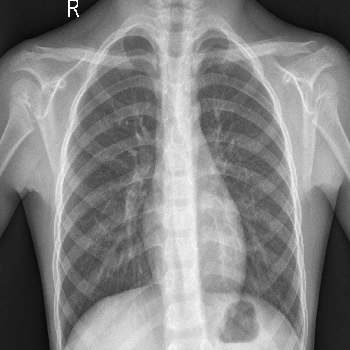

In [60]:
test_image_batch, label_batch = next(test_generator)

image = Image.fromarray((test_image_batch[0] * 255).astype('uint8').squeeze())

image

โค้ดนี้มีวัตถุประสงค์เพื่อดึงข้อมูลภาพและป้าย (label) จาก generator สำหรับชุดทดสอบ จากนั้นสร้างออบเจ็กต์ภาพ (PIL Image) จากอาเรย์ของภาพใน batch แรก รายละเอียดมีดังนี้:


test_image_batch, label_batch = next(test_generator)
 • เรียกใช้ฟังก์ชัน next() เพื่อดึง batch ถัดไปของข้อมูลจาก test_generator
 • test_image_batch คืออาเรย์ของภาพ (เช่น ขนาด [batch_size, height, width, channels])
 • label_batch คืออาเรย์ของป้ายกำกับที่สอดคล้องกับภาพใน batch นั้น


image = Image.fromarray((test_image_batch[0] * 255).astype('uint8').squeeze())
 • test_image_batch[0] คือการเลือกภาพตัวแรกจาก batch ซึ่งภาพนี้อาจมีค่าแบบ floating point อยู่ในช่วง [0, 1]
 • การคูณด้วย 255 จะปรับค่าในอาเรย์ให้มีช่วง [0, 255] ซึ่งเป็นช่วงที่ใช้ทั่วไปในภาพที่มีข้อมูลประเภท uint8
 • .astype('uint8') ทำการแปลงชนิดข้อมูลของอาเรย์ให้เป็น unsigned 8-bit integer
 • .squeeze() ใช้เพื่อลบมิติที่มีขนาด 1 ออก (ตัวอย่างเช่น ถ้าเป็นภาพสีหรือภาพขาวดำที่ไม่ต้องการมิติที่เกินมานี้)
 • Image.fromarray() ใช้สร้างอ็อบเจ็กต์ภาพจากอาเรย์ที่ได้ ด้วยไลบรารี PIL (Pillow)


image
 • โค้ดนี้จะแสดง (หรือเรียก) ออบเจ็กต์ image ซึ่งเป็นภาพที่แปลงมาจากข้อมูลใน batch ถ้าอยู่ใน Notebook โดยทั่วไปภาพจะถูกแสดงผลทันที


โดยสรุป โค้ดนี้ทำการดึงภาพตัวแรกจากชุดทดสอบ ปรับปรุงค่าให้เหมาะสมแล้วสร้างเป็นภาพที่สามารถแสดงผลได้ด้วย PIL ครับ

In [61]:
label_batch[:32]

array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
      dtype=float32)

คำสั่ง label_batch[:32] หมายถึงการเลือกข้อมูลในตัวแปร label_batch ตั้งแต่ตำแหน่งเริ่มต้น 0 จนถึงตำแหน่ง 31 ซึ่งเป็นการเลือกหรือดึงข้อมูลออกมา 32 รายการแรกจาก label_batch นั่นเอง
ตัวอย่างเช่น หาก label_batch เป็นอาเรย์หรือรายการที่มีข้อมูลป้ายกำกับ (labels) ของภาพใน batch ดังนั้นคำสั่งนี้จะช่วยให้คุณสามารถดูหรือใช้งานป้ายกำกับของ 32 ภาพแรกใน batch ได้ครับ

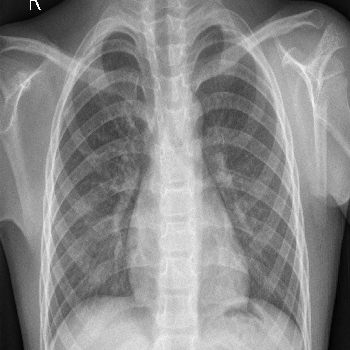

In [62]:
image = Image.fromarray((test_image_batch[11] * 255).astype('uint8').squeeze())

image

โค้ดนี้มีวัตถุประสงค์เพื่อสร้างออบเจ็กต์ภาพ (PIL Image) จากข้อมูลในอาเรย์ของภาพใน batch โดยเลือกภาพที่ตำแหน่ง index 11 (ภาพที่ 12 ในการนับแบบเริ่มต้นที่ 0) โดยมีขั้นตอนดังนี้:


test_image_batch[11]
 • เลือกภาพที่ตำแหน่งที่ 11 จาก test_image_batch ซึ่งเป็น batch ของภาพที่มีค่าอยู่ในช่วง [0, 1] (โดยปกติ)


(test_image_batch[11] * 255)
 • คูณทุกค่าในอาเรย์ด้วย 255 เพื่อเปลี่ยนช่วงค่าเป็น [0, 255] ซึ่งเป็นช่วงที่เหมาะสมสำหรับข้อมูลแบบ uint8


.astype('uint8')
 • แปลงชนิดข้อมูลของอาเรย์ให้เป็น unsigned 8-bit integer (uint8) เพื่อให้เหมาะสำหรับการแสดงภาพ


.squeeze()
 • ลบมิติที่มีขนาด 1 ออก (เช่น หากข้อมูลมีมิติที่ไม่จำเป็น) เพื่อจัดรูปแบบให้เหมาะสมกับการแปลงเป็นภาพ
  (ในบางกรณีอาจใช้กับข้อมูลที่มีมิติพิเศษ เช่น [height, width, 1] ถ้าภาพเป็นแบบเกรย์สเกล)


Image.fromarray(...)
 • ฟังก์ชัน fromarray() จากไลบรารี PIL ใช้สร้างออบเจ็กต์ภาพจากอาเรย์ที่เตรียมไว้


image
 • เมื่อเรียก image ใน Notebook ภาพที่ถูกสร้างมาจะถูกแสดงผลออกมา


สรุปคือ โค้ดนี้ทำการเลือกภาพตัวที่ 12 ในชุด test_image_batch ปรับเปลี่ยนค่าให้อยู่ในรูปแบบที่สามารถแสดงผลด้วย PIL จากนั้นสร้างออบเจ็กต์ภาพที่สามารถแสดงใน environment เช่น Jupyter Notebook ได้ครับ

In [63]:
messages = [
    {
        "role": "system",
        "content": [{"type": "text", "text": "You are an expert radiologist."}]
    },
    {
        "role": "user",
        "content": [
            {"type": "text", "text": "Describe this X-ray ดูว่าเป็น Pneumonia หรือไม่ (ตอบสั้นกระชับเป็นภาษาไทย)"},
            {"type": "image", "image": image}
        ]
    }
]

โค้ดนี้สร้างตัวแปร messages ซึ่งเป็นรายการ (list) ของข้อความสำหรับส่งต่อให้กับระบบโมเดลภาษาและภาพ โดยมีรายละเอียดดังนี้:


ข้อความกับ role "system":
 • ระบุข้อความในส่วน system ให้กับโมเดลว่า "You are an expert radiologist."
 • ข้อความนี้ทำหน้าที่เป็นคำสั่งสอน (instruction) เพื่อบอกให้โมเดลปฏิบัติตัวในฐานะผู้เชี่ยวชาญด้านรังสีวิทยา


ข้อความกับ role "user":
 • ประกอบด้วยข้อความและภาพ
  - ข้อความที่ให้คือ "Describe this X-ray ดูว่าเป็น Pneumonia หรือไม่ (ตอบสั้นกระชับเป็นภาษาไทย)"
   หมายความว่าให้โมเดลอธิบายภาพ X-ray ที่ส่งไป โดยพิจารณาว่ามีลักษณะของ Pneumonia หรือไม่ และให้ตอบเป็นภาษาไทยในรูปแบบที่สั้นและกระชับ
  - นอกจากนี้ มีการแนบภาพ (image) โดยออบเจ็กต์ image ที่สร้างขึ้นมาก่อนหน้านี้ ซึ่งอยู่ในรูปแบบของ PIL Image


สรุปแล้ว โค้ดนี้จัดเตรียม input สำหรับโมเดลที่รองรับการประมวลผลข้อมูลหลากหลายประเภท (ข้อความและภาพ) โดยมีการกำหนดบทบาทของผู้ใช้งานและคำสั่งที่ชัดเจน เพื่อให้งานวิเคราะห์ภาพ X-ray เป็นไปตามคำสั่งที่ระบุไว้ครับ

In [64]:
output = pipe(text=messages, max_new_tokens=300)
print(output[0]["generated_text"][-1]["content"])

จากภาพ X-ray ที่ให้มา ดูเหมือนจะไม่พบภาวะปอดบวม (Pneumonia) โดยทั่วไปแล้ว ปอดจะปรากฏเป็นสีขาว (lucent) เนื่องจากเป็นอากาศ แต่ภาพนี้ไม่มีลักษณะที่บ่งบอกถึงการอักเสบหรือการสะสมของของเหลวในปอด



โค้ดนี้มีวัตถุประสงค์สองอย่างหลักคือ:


เรียกใช้งาน pipeline (pipe) ที่รับ input เป็นข้อความและภาพจากตัวแปร messages โดยกำหนดจำนวน token ใหม่สูงสุดที่สามารถสร้างได้ (max_new_tokens) ที่ 300 ตัว
 • output = pipe(text=messages, max_new_tokens=300)
  - คำสั่งนี้จะส่งข้อความและภาพที่อยู่ใน messages เข้าไปใน pipeline ซึ่งอาจเป็นโมเดลที่รองรับข้อมูลแบบ multi-modal (ข้อความและภาพ)
  - โมเดลจะประมวลผลตามคำสั่งและสร้างผลลัพธ์เพิ่มเติมภายในข้อความที่สร้างขึ้น


แสดงผลลัพธ์ที่สร้างขึ้น
 • print(output[0]["generated_text"][-1]["content"])
  - output เป็นรายการ (list) ของผลลัพธ์ที่ได้จาก pipeline
  - output[0] คือเอาต์พุตขององค์ประกอบแรก
  - "generated_text" เป็นคีย์ที่เก็บข้อความที่โมเดลสร้างขึ้นในรูปแบบของรายการ
  - [-1] ใช้ดึงข้อความตัวสุดท้ายในรายการนั้น
  - ["content"] คือการดึงเนื้อหาจากข้อความที่ถูกจัดเก็บไว้
  - สุดท้าย print() จะแสดงเนื้อหาที่ได้ออกมาทาง console


สรุปคือ โค้ดนี้ทำงานโดยการส่งข้อมูล (ข้อความและภาพ) ไปยังโมเดลผ่าน pipeline เพื่อขอให้โมเดลสร้างคำตอบ แล้วจึงนำข้อความที่โมเดลสร้างขึ้นมา (ข้อความสุดท้าย) มาแสดงผลใน console ครับ

In [65]:
image_array = np.array(image)
image_array.shape

(350, 350)

โค้ดนี้ทำงานโดยการแปลงอ็อบเจ็กต์ PIL Image (ที่เก็บอยู่ในตัวแปร image) ให้เป็นอาเรย์ของ NumPy จากนั้นเรียกดูรูปร่าง (shape) ของอาเรย์นั้น
ขั้นตอน:


image_array = np.array(image)
 • ฟังก์ชัน np.array() แปลงออบเจ็กต์ image ให้เป็นอาเรย์ของ NumPy
 • ผลลัพธ์คือ image_array จะมีข้อมูลของภาพในรูปแบบอาเรย์


image_array.shape
 • คำสั่งนี้จะให้รูปร่าง (dimensions) ของอาเรย์ เช่น (ความสูง, ความกว้าง) สำหรับภาพเกรย์สเกล หรือ (ความสูง, ความกว้าง, จำนวน channel) สำหรับภาพสี


ดังนั้น ผลลัพธ์ที่ได้จาก image_array.shape ขึ้นอยู่กับประเภทของภาพที่ส่งเข้าไป เช่น
• หากเป็นภาพขาวดำ (grayscale) อาจได้รูปร่างประมาณ (H, W)
• หากเป็นภาพ RGB อาจได้รูปร่างประมาณ (H, W, 3)
สรุปคือ โค้ดนี้ใช้แปลงภาพเป็นอาเรย์และตรวจสอบขนาดของข้อมูลภาพที่ได้ครับ

In [66]:
image_array = image_array.reshape(1, img_size[0], img_size[1], 1)

บรรทัดนี้ทำการปรับเปลี่ยนรูปร่าง (reshape) ของอาเรย์ภาพให้ตรงกับรูปแบบที่โมเดลต้องการรับเข้าไป โดยปรับให้มีมิติ 4 มิติ ในรูปแบบ (จำนวนตัวอย่าง, ความสูง, ความกว้าง, ช่องสี) ซึ่งในที่นี้:
• ค่าของ 1 แรก หมายถึงจำนวนภาพในแบทช์ (batch size) คือ 1 ภาพ
• img_size[0] คือความสูงของภาพ
• img_size[1] คือความกว้างของภาพ
• ส่วนสุดท้ายเป็น 1 เพราะเป็นภาพที่มีช่องทางเดียว (ช่องสีเดียว) เช่น ภาพเกรย์สเกล
สรุปคือ โค้ดนี้ทำให้ image_array มีรูปร่างเป็น (1, สูง, กว้าง, 1) เพื่อให้สามารถเป็น input ของโมเดลที่รองรับข้อมูลในรูปแบบ 4 มิติได้ครับ

In [67]:
image_array.shape

(1, 350, 350, 1)

หลังจากที่เราใช้คำสั่ง reshape กับ image_array รูปร่างของมันจะกลายเป็น (1, img_size[0], img_size[1], 1) ซึ่งแต่ละองค์ประกอบหมายความว่า:
• 1 คือ batch size ซึ่งมีเพียงภาพเดียว
• img_size[0] คือความสูงของภาพ
• img_size[1] คือความกว้างของภาพ
• 1 คือจำนวน channel ของภาพ (ในที่นี้คือภาพเกรย์สเกล)
ดังนั้น เมื่อสั่ง image_array.shape จะได้ผลลัพธ์เป็น (1, img_size[0], img_size[1], 1) ครับ

In [68]:
image_array = image_array / 255.0

บรรทัดนี้ใช้ปรับสเกลค่าพิกเซลของภาพให้ให้อยู่ในช่วง 0 ถึง 1 โดยการหารแต่ละค่าสีด้วย 255.0 ซึ่งเป็นค่าสูงสุดของค่าพิกเซลในภาพแบบ 8-bit
สรุปคือ เมื่อทำบรรทัดนี้ พิกเซลของ image_array จะถูกแปลงจากช่วง 0-255 เป็นช่วง 0-1 ครับ

In [69]:
cnn_prediction = model.predict(image_array)

predicted_class_index = (cnn_prediction > 0.5).astype("int32")[0][0]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


บรรทัดแรก (cnn_prediction = model.predict(image_array)) ทำหน้าที่ส่งข้อมูลภาพที่อยู่ใน image_array ให้กับโมเดล CNN เพื่อทำการทำนาย (prediction) ผลลัพธ์ที่ได้จะถูกเก็บไว้ในตัวแปร cnn_prediction ซึ่งส่วนมากจะอยู่ในรูปแบบอาเรย์ของค่าความน่าจะเป็นที่ออกมาจากเลเยอร์สุดท้ายของโมเดล
ส่วนบรรทัดที่สอง (predicted_class_index = (cnn_prediction > 0.5).astype("int32")[0][0]) ทำการตัดสินใจคลาสของภาพโดยใช้ threshold ที่ 0.5 โดยมีรายละเอียดดังนี้:
 • (cnn_prediction > 0.5) ทำการเปรียบเทียบค่าความน่าจะเป็นใน cnn_prediction กับ 0.5 และส่งกลับเป็นบูลีน (True/False)
 • .astype("int32") แปลงผลลัพธ์บูลีนเป็นตัวเลขจำนวนเต็ม (โดย True จะถูกแปลงเป็น 1 และ False เป็น 0)
 • [0][0] ดึงค่าแรกที่อยู่ในอาเรย์ ซึ่งถือเป็นการเตรียมผลลัพธ์ให้มีรูปแบบเป็นสเกลาร์
สรุปคือ โค้ดส่วนนี้จะทำการส่งภาพเข้าโมเดลและตัดสินใจคลาสของภาพโดยใช้ค่า threshold ที่ 0.5 ถ้าค่าความน่าจะเป็นมากกว่า 0.5 ก็จะถูกจัดเป็นคลาส 1 (หรือคลาสที่แทนด้วย 1) แต่ถ้าน้อยกว่าหรือเท่ากับ 0.5 จะจัดเป็นคลาส 0 นั่นเองครับ

In [70]:
predicted_class_index

np.int32(0)

ตัวแปร predicted_class_index ที่เราได้มาจากบรรทัดโค้ดก่อนหน้านี้ (predicted_class_index = (cnn_prediction > 0.5).astype("int32")[0][0]) คือค่าที่ใช้แทนการตัดสินผลการทำนายของโมเดล CNN ว่าภาพที่เรานำเข้าอยู่ในคลาสใด โดยมีการเปรียบเทียบค่าความน่าจะเป็นของโมเดลกับค่า 0.5
รายละเอียด:
• โมเดลส่งกลับค่าความน่าจะเป็นในตัวแปร cnn_prediction ซึ่งโดยปกติจะอยู่ในช่วง 0 ถึง 1
• เมื่อเราใช้ (cnn_prediction > 0.5) โค้ดนี้จะเปรียบเทียบค่าใน cnn_prediction กับ 0.5 แล้วให้ผลลัพธ์เป็น True (ถ้าค่ามากกว่า 0.5) หรือ False (ถ้าน้อยกว่าหรือเท่ากับ 0.5)
• จากนั้น .astype("int32") จะแปลงค่า True เป็น 1 และ False เป็น 0
• [0][0] ถูกใช้เพื่อดึงค่าตัวแรกออกมาจากอาเรย์ ซึ่งสรุปได้ว่า predicted_class_index คือเลข 0 หรือ 1 โดย 1 แสดงว่าความน่าจะเป็นมีค่าสูงกว่า 0.5 (คลาสที่ 1) และ 0 แสดงว่าต่ำกว่า 0.5 (คลาสที่ 0)
ดังนั้น predicted_class_index จึงเป็นตัวแปรที่บอกให้ทราบว่าผลลัพธ์สุดท้ายของการทำนายภาพเป็นคลาสไหนในงานจำแนกภาพครับ

In [71]:
labels

['normal', 'opacity']

คำว่า labels โดยทั่วไปจะหมายถึงตัวแปรที่เก็บข้อมูลชื่อหรือตัวระบุของแต่ละคลาสในการจำแนกข้อมูล ตัวอย่างเช่น ในงานจำแนกภาพที่มีสองคลาส (เช่น "แมว" กับ "สุนัข") เราอาจจะประกาศตัวแปร labels เป็นลิสต์หรือดิกชันนารีเพื่อเก็บชื่อของคลาสแต่ละประเภทไว้ โดยอาจเขียนโค้ดประมาณนี้

ในกรณีที่ใช้ลิสต์
labels = ["แมว", "สุนัข"]
โดยที่ labels[0] คือ "แมว" และ labels[1] คือ "สุนัข"
หรือในกรณีที่ใช้ดิกชันนารี
labels = {0: "แมว", 1: "สุนัข"}
หลังจากที่เราได้ผลลัพธ์การทำนายจากโมเดลแล้ว (เช่น predicted_class_index ซึ่งมีค่า 0 หรือ 1) เราสามารถใช้ตัวแปร labels เพื่อแสดงชื่อของคลาสที่โมเดลทำนายได้ เช่น

print("โมเดลทำนายว่าภาพเป็น:", labels[predicted_class_index])
สรุปคือ labels เป็นตัวแปรที่ใช้แปลหมายเลขของคลาส (เช่น 0 หรือ 1) เป็นชื่อหรือคำอธิบายที่เข้าใจง่ายเกี่ยวกับประเภทของภาพนั้น ๆ ครับ

In [72]:
predicted_class_label = labels[predicted_class_index]

print(f"CNN Model Prediction: {predicted_class_label}")
print(f"Prediction Probability: {cnn_prediction[0][0]:.4f}")

CNN Model Prediction: normal
Prediction Probability: 0.1389


บรรทัดแรก (predicted_class_label = labels[predicted_class_index]) จะใช้ตัวแปร predicted_class_index ซึ่งเป็นผลลัพธ์จากโมเดล (0 หรือ 1) มาอ้างอิงในตัวแปร labels เพื่อดึงชื่อหรือป้าย (label) ของคลาสที่โมเดลทำนายออกมาเก็บไว้ในตัวแปร predicted_class_label
ต่อมาจะมีการแสดงผลออกมาดังนี้
• print(f"CNN Model Prediction: {predicted_class_label}")
 → แสดงผลข้อความ "CNN Model Prediction:" ตามด้วยชื่อคลาสที่โมเดลทำนาย
• print(f"Prediction Probability: {cnn_prediction[0][0]:.4f}")
 → แสดงผลข้อความ "Prediction Probability:" ตามด้วยค่าความน่าจะเป็นของการทำนายจากโมเดล (ค่าที่อยู่ใน cnn_prediction) โดยมีการจัดรูปแบบเป็นตัวเลขทศนิยม 4 ตำแหน่ง
สรุปคือ โค้ดส่วนนี้จะแปลผลการทำนายของโมเดลให้อยู่ในรูปแบบที่เข้าใจง่าย โดยแสดงทั้งชื่อคลาสที่ทำนายและค่าความน่าจะเป็นที่โมเดลให้ไว้ครับ

In [73]:
for layer in reversed(model.layers):
    if isinstance(layer, tf.keras.layers.Conv2D):
        last_conv_layer_name = layer.name
        break

print(f"Last convolutional layer name: {last_conv_layer_name}")

Last convolutional layer name: last_conv_layer


โค้ดส่วนนี้ใช้สำหรับค้นหาเลเยอร์แบบ Convolutional (Conv2D) ตัวสุดท้ายในโมเดล CNN ซึ่งมีขั้นตอนดังนี้:


for layer in reversed(model.layers):
  - ทำการวนลูปผ่านเลเยอร์ทั้งหมดของโมเดลในลำดับย้อนกลับ (เริ่มจากเลเยอร์สุดท้ายไปหาเลเยอร์แรก)


if isinstance(layer, tf.keras.layers.Conv2D):
  - ตรวจสอบว่าเลเยอร์ตอนนี้เป็น instance ของ tf.keras.layers.Conv2D หรือไม่


last_conv_layer_name = layer.name
  - ถ้าเจอเลเยอร์ที่เป็น Conv2D ก็จะเอาชื่อของเลเยอร์นั้น (layer.name) ไปเก็บในตัวแปร last_conv_layer_name แล้วก็ใช้ break เพื่อออกจากลูปทันที


print(f"Last convolutional layer name: {last_conv_layer_name}")
  - แสดงชื่อของเลเยอร์ Convolutional ตัวสุดท้ายที่เจอ


สรุปคือ โค้ดนี้ช่วยให้เราทราบชื่อของเลเยอร์ Convolutional สุดท้ายในโมเดล CNN ซึ่งอาจถูกใช้ในการทำ gradient-class activation mapping (Grad-CAM) หรือเทคนิคอื่น ๆ ที่ต้องการข้อมูลจากเลเยอร์นี้ครับ

In [74]:
from tf_keras_vis.gradcam import Gradcam

บรรทัดนี้คือการนำเข้า (import) คลาส Gradcam จากโมดูล tf_keras_vis.gradcam ซึ่งเป็นส่วนหนึ่งของไลบรารี tf-keras-vis ที่ใช้สำหรับสร้างภาพแสดงว่าโมเดล CNN ให้ความสำคัญกับส่วนใดของภาพในการตัดสินใจ (เช่น Grad-CAM คือ Gradient-weighted Class Activation Mapping)
โดยมีรายละเอียดดังนี้:
• from tf_keras_vis.gradcam import Gradcam
  - ทำการ import คลาส Gradcam ซึ่งจะช่วยให้เราสามารถสร้างภาพ heatmap ที่อธิบายว่าชิ้นส่วนไหนของภาพที่มีผลต่อการทำนายของโมเดลได้
  - ไลบรารี tf-keras-vis นี้ถูกออกแบบมาช่วยในการวิเคราะห์และทำความเข้าใจโมเดล CNN ด้วยเทคนิค visualization ต่าง ๆ เช่น Grad-CAM, Score-CAM เป็นต้น
สรุปคือ บรรทัดนี้เตรียมความพร้อมให้เราใช้ฟังก์ชันและเมธอดในคลาส Gradcam เพื่อสร้าง Grad-CAM visualization ช่วยในการอธิบายผลลัพธ์ที่โมเดลได้ทำนายครับ

In [75]:
gradcam = Gradcam(model, model_modifier=None, clone=True)

บรรทัดโค้ดนี้ใช้สำหรับสร้างอินสแตนซ์ของคลาส Gradcam เพื่อเตรียมความพร้อมสำหรับการสร้าง Grad-CAM visualization โดยมีรายละเอียดดังนี้:
• gradcam = Gradcam(model, model_modifier=None, clone=True)
- model: ส่งผ่านโมเดลที่เราต้องการวิเคราะห์เข้าไป ซึ่งเป็นโมเดลที่เราฝึกไว้ ตัว Gradcam จะใช้โมเดลนี้ในการคำนวณ gradient และ activation maps
- model_modifier=None: เมื่อต้องการปรับเปลี่ยนหรือแก้ไขโมเดลก่อนนำไปคำนวณ Grad-CAM (เช่น ลบเลเยอร์สุดท้ายออกหรือเพิ่มการแก้ไขอื่น ๆ) เราสามารถส่งฟังก์ชันแก้ไขโมเดลผ่านพารามิเตอร์นี้ แต่ในที่นี้เราไม่ต้องการแก้ไขอะไรจึงใส่เป็น None
- clone=True: เมื่อค่า clone ถูกตั้งเป็น True Gradcam จะทำการ clone (ก๊อปปี้) โมเดลที่ส่งเข้าไป ซึ่งจะช่วยให้เราสามารถทดลองกับโมเดลที่ถูกแก้ไขสำหรับ Grad-CAM โดยไม่กระทบกับโมเดลต้นฉบับที่เราใช้ในการฝึกหรือใช้งานอื่น ๆ
สรุปคือ บรรทัดนี้คือการเตรียมวัตถุ gradcam จากคลาส Gradcam โดยใช้โมเดลที่มีอยู่ (และ clone โมเดลออกมาใหม่) เพื่อให้เราสามารถสร้าง visualization แบบ Grad-CAM และตรวจสอบว่าชิ้นส่วนใดของภาพที่โมเดลให้ความสำคัญในการตัดสินใจครับ

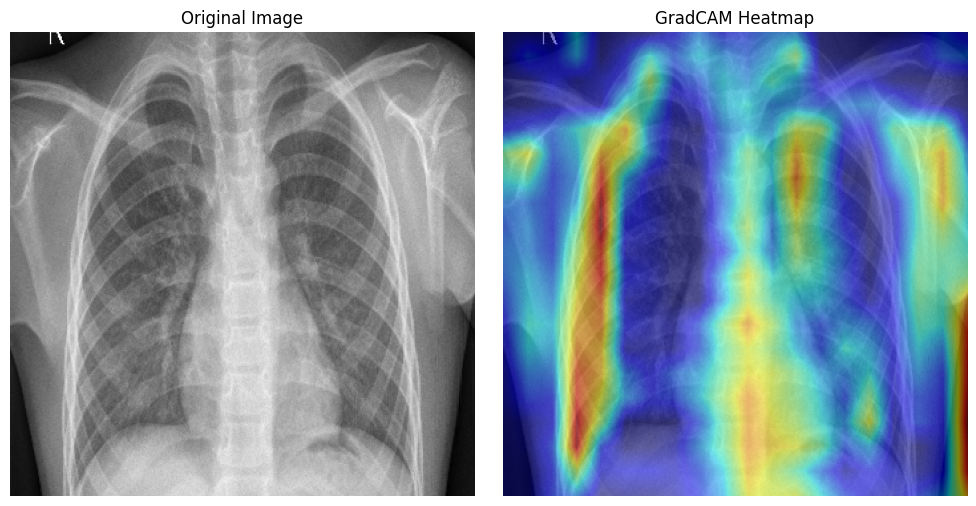

In [76]:
from tf_keras_vis.utils.model_modifiers import ReplaceToLinear
from tf_keras_vis.utils.scores import CategoricalScore

def custom_score(output):
    return output

heatmap = gradcam(custom_score,
                  image_array,
                  penultimate_layer=last_conv_layer_name)

heatmap = heatmap[0]

fig, axes = plt.subplots(1, 2, figsize=(10, 5))

# Display original image
axes[0].imshow(image.convert('RGB'))
axes[0].set_title('Original Image')
axes[0].axis('off')

# Display GradCAM heatmap
axes[1].imshow(image.convert('RGB'))
axes[1].imshow(heatmap, cmap='jet', alpha=0.5) # Overlay the heatmap
axes[1].set_title('GradCAM Heatmap')
axes[1].axis('off')

plt.tight_layout()
plt.show()

โค้ดนี้เป็นการใช้ GradCAM (Gradient-weighted Class Activation Mapping) ซึ่งเป็นเทคนิคสำคัญใน Explainable AI (XAI) มาอธิบายแต่ละส่วน:

ส่วนประกอบของโค้ด
1. Import Libraries
python
from tf_keras_vis.utils.model_modifiers import ReplaceToLinear
from tf_keras_vis.utils.scores import CategoricalScore

Copy

tf_keras_vis: ไลบรารีสำหรับ visualization ของโมเดล Keras/TensorFlow
ReplaceToLinear: แปลง activation function เป็น linear เพื่อให้ gradient ผ่านได้ดีขึ้น
CategoricalScore: สำหรับคำนวณ score ของแต่ละคลาส
2. Custom Score Function
python
def custom_score(output):
    return output

Copy

ฟังก์ชันนี้กำหนดว่าจะวัด "ความสำคัญ" ยังไง
ในกรณีนี้ return ทั้งหมด (วัดทุกคลาส)
3. GradCAM Generation
python
heatmap = gradcam(custom_score,
                  image_array,
                  penultimate_layer=last_conv_layer_name)

Copy

สร้าง heatmap แสดงว่าส่วนไหนของรูปที่โมเดลใส่ใจมากที่สุด
penultimate_layer: ชั้น convolutional สุดท้ายก่อน classification
4. Visualization
python
# แสดงรูปต้นฉบับและ heatmap ที่ overlay กัน

Copy

คำแนะนำสำหรับการใช้งาน
1. ปรับปรุง Score Function
python
# สำหรับคลาสเฉพาะ
def target_class_score(output):
    return output[:, target_class_index]

# สำหรับ top-k classes
def top_k_score(output):
    return tf.nn.top_k(output, k=3).values

Copy

2. เพิ่มการวิเคราะห์
python
# คำนวณค่าสถิติของ heatmap
print(f"Max activation: {heatmap.max():.4f}")
print(f"Mean activation: {heatmap.mean():.4f}")
print(f"Std activation: {heatmap.std():.4f}")

Copy

3. ปรับแต่ง Visualization
python
# ใช้ colormap ต่างๆ
axes[1].imshow(heatmap, cmap='hot', alpha=0.6)  # หรือ 'viridis', 'plasma'

# เพิ่ม colorbar
im = axes[1].imshow(heatmap, cmap='jet', alpha=0.5)
plt.colorbar(im, ax=axes[1])

Copy

4. การใช้งานขั้นสูง
python
# GradCAM++ (ปรับปรุงแล้ว)
heatmap = gradcam_plus_plus(custom_score, image_array)

# Score-CAM (ไม่ใช้ gradient)
heatmap = scorecam(custom_score, image_array)

# LayerCAM
heatmap = layercam(custom_score, image_array)

Copy

5. เคล็ดลับการใช้งาน
✅ ข้อดี:

เข้าใจได้ง่ายว่าโมเดล "มอง" อะไร
ช่วย debug โมเดล
เหมาะสำหรับ CNN
⚠️ ข้อระวัง:

GradCAM อาจไม่แม่นยำ 100%
ขึ้นกับชั้น conv ที่เลือก
ควรใช้ร่วมกับเทคนิคอื่น
💡 แนะนำเพิ่มเติม:

ทดลองกับหลายๆ ชั้น conv
เปรียบเทียบกับ LIME, SHAP
ใช้กับ validation set เพื่อวัดความน่าเชื่อถือ
พิจารณาใช้ Guided GradCAM สำหรับรายละเอียดมากขึ้น